In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# Data Pre-Processing

## Combining Data

In [2]:
COMBINE_DATASETS = False
if COMBINE_DATASETS:
    old_names = ['29_06','30_06','01_07','02_07','03_07','04_07','05_07','06_07'] + [f'retry_run{n}' for n in range(1,7)]
    old_locations = [f"../experiments/collected_data_{fname}.csv" for fname in old_names]
    new_locations = ["../experiments/collected_data_berlinersplit.csv", "../experiments/collected_data_baserulesafter.csv"]
    old_raw = pd.concat([pd.read_csv(location) for location in old_locations])
    new_raw = pd.concat([pd.read_csv(location) for location in new_locations])
    per_run_old = old_raw.groupby(['seed','algorithm']).first()
    per_run_new = new_raw.groupby(['seed','algorithm']).first()
    per_run_upd = per_run_old.copy()
    per_run_upd.loc[per_run_new.index] = per_run_new
    upd_raw = per_run_upd.reset_index()[list(old_raw.columns)]
    upd_raw.to_csv("../experiments/combined_data.zip", index=False, compression={'method':'zip', 'archive_name':"combined_data.csv"})
    del old_names, old_locations, new_locations, old_raw, new_raw, per_run_old, per_run_new, per_run_upd, upd_raw

## Loading Data

In [3]:
# main_raw = pd.read_csv("../experiments/combined_data.zip")
# main_raw = pd.read_csv("../experiments/collected_data_alt_compare.csv")
main_raw = pd.read_csv("../experiments/combined_data_153.zip")

In [4]:
# Dropping 'Legacy' data - not described in paper:
main_raw = main_raw[(main_raw["style"] != "Legacy") & (main_raw["style"] != "BerlinerSplit")]

In [5]:
main = main_raw.copy()
main.PS = main_raw.PS == "yes"
main.intractable = main_raw.intractable == "yes"
algos = main_raw.algorithm.unique(); algos.sort()
for algo in algos:
    main[algo] = main_raw.algorithm == algo

In [6]:
# solved by all:
gby = main[~main.intractable].groupby('seed')
counts = gby.algorithm.count()
seeds_all = main.seed.isin(counts[counts==len(algos)].index)
main_all = main[seeds_all].drop(columns=list(algos)+['intractable'])
del gby, counts, seeds_all

In [7]:
# solved by none:
gby = main[main.intractable].groupby('seed')
counts = gby.algorithm.count()
seeds_none = main.seed.isin(counts[counts==len(algos)].index)
main_none = main[seeds_none].drop(columns=list(algos)+['intractable'])
main_none['distance'] = main_none.sepValue / main_none.range
del gby, counts, seeds_none

## Validation:

In [8]:
per_tree = main_raw[main_raw.intractable == "no"].groupby('seed')
_num_solutions = per_tree.solution.apply(lambda x : len(x.unique()))
_num_sepvals = per_tree.sepValue.apply(lambda x : len(x.unique()))
df0 = main.join(pd.DataFrame({"numsol": _num_solutions, "numsep": _num_sepvals}), on="seed").fillna(0)
print("if all goes well, the following printed frame is empty:")
display(df0[(df0.numsol > 1) & (df0.numsep > 1)])
del df0, _num_sepvals, _num_solutions, per_tree

if all goes well, the following printed frame is empty:


,style,algorithm,growth,PS,num_alts,force_chance,seed,range,width,seconds,...,berlin-2D,berlin-2R,berlin-3D,berlin-3R,berlin-AD,berlin-AR,prefer-DR,randomize,numsol,numsep


In [50]:
algos3 = ["always-PB","prefer-DR","randomize","alternate","berlin-2D","berlin-3D","berlin-AD","berlin-2R","berlin-3R","berlin-AR"]
algos3 += ["altern-DB","DB-AR-0.8","DB-AR-1.0","DB-AR-1.4","DB-AR-1.6","DB-AR-2.0"]

algos3_labels = [
    "Best-First",
    "Disprove-Rest",
    "Randomized",
    "Alternated",
    "Berliner-2D",
    "Berliner-3D",
    "Berliner-AD",
    "Berliner-2R",
    "Berliner-3R",
    "Berliner-AR",
    "DB-ALT",
    "DB-AR-0.8",
    "DB-AR-1.0",
    "DB-AR-1.4",
    "DB-AR-1.6",
    "DB-AR-2.0"
]
algos3dict = {algos3[i] : algos3_labels[i] for i in range(len(algos3))}

styleorder = ["Berliner","Palay","BaseRulesBefore","BaseRulesAfter"]
stylelabels = ["Berliner","Palay","AdjustBefore","AdjustAfter"]
styledict = {styleorder[i]:stylelabels[i] for i in range(4)}

algorithm_colors = {
    # CONTROL
    "always-PB":"#0270c9",
    "prefer-DR":"#0c3e66",
    # SIMPLE
    "randomize":"#7c4991",##7c4991
    "alternate":"#9961ed",
    # BERLINER xD
    "berlin-2D":"#f5bf78",
    "berlin-3D":"#eda13e",
    "berlin-AD":"#f58b00",
    # BERLINER xR
    "berlin-2R":"#81b77b",
    "berlin-3R":"#56a358",
    "berlin-AR":"#168337",
    # DISPROVE-BEST ALT
    "altern-DB":"#c24f92",  #"#ba237b",
    # DISPROVE-BEST AR-y
    "DB-AR-0.8":"#de9595",
    "DB-AR-1.0":"#de6f6f",
    "DB-AR-1.4":"#de4b4b",
    "DB-AR-1.6":"#de2626",
    "DB-AR-2.0":"#ab0000" #"#de0000"
}

def frame_this(ax):
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

## Compute number of problems solved by algorithm pair

The following figure shows the number of trees that were solved (`not intractable`) by any pair of algorithms. You can also read the total number of trees solved for a specific algorithm off the diagonal of this figure:

Overall, 69.2% of trees are solved by any algorithm.
The best algorithm could solve 97.66% of all solved trees


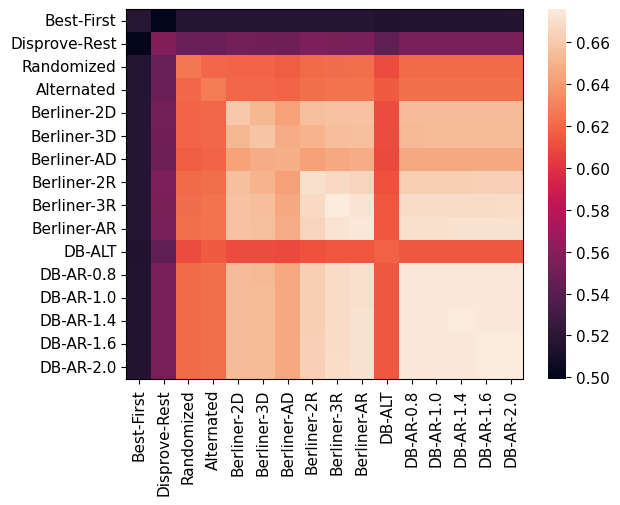

In [16]:
altm = main

gby = altm[~altm.intractable].groupby('seed')
pair_counts = {a: {b: (gby[a].any() & gby[b].any()).sum() for b in algos} for a in algos}
main_pairs = pd.DataFrame(pair_counts)
del gby, pair_counts

number_of_trees_solved_total = altm[~altm.intractable].groupby('seed').algorithm.count().size
g = sns.heatmap(main_pairs.loc[algos3, algos3] / altm.seed.unique().size, xticklabels=algos3_labels, yticklabels=algos3_labels)
g.tick_params(axis='both', which='major', labelsize=11)
g.collections[0].colorbar.ax.tick_params(labelsize=11)
# plt.title("Fraction of Solved Trees per Pair of Algorithms")
print(f"Overall, {100*number_of_trees_solved_total / altm.seed.unique().size:.1f}% of trees are solved by any algorithm.")
print(f"The best algorithm could solve {100*main_pairs.max().max() / number_of_trees_solved_total:.2f}% of all solved trees")

frame_this(g)

plt.savefig("../figures/fraction_ALL_trees_solved.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [25]:
(main_pairs / altm.seed.unique().size)["always-PB"].sort_values()

prefer-DR    0.499362
altern-DB    0.514751
DB-AR-0.8    0.515836
DB-AR-1.0    0.515836
DB-AR-1.4    0.515896
DB-AR-1.6    0.515914
DB-AR-2.0    0.515954
berlin-2R    0.516703
berlin-2D    0.516796
berlin-3R    0.516993
berlin-3D    0.517051
berlin-AR    0.517106
randomize    0.517134
berlin-AD    0.517164
alternate    0.517169
always-PB    0.517785
Name: always-PB, dtype: float64

In [14]:
# Out[10] == main.corr()
Out[10]["intractable"];

Overall, 75.5% of Berliner trees are solved by any algorithm.
The best algorithm could solve 96.44% of all solved Berliner trees


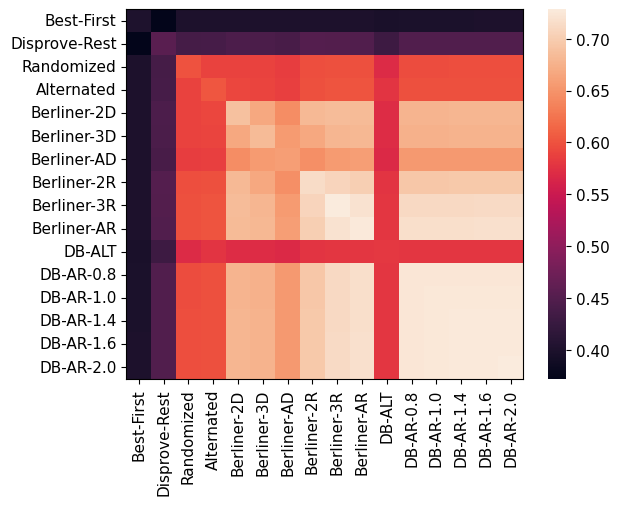

Overall, 77.0% of Palay trees are solved by any algorithm.
The best algorithm could solve 97.56% of all solved Palay trees


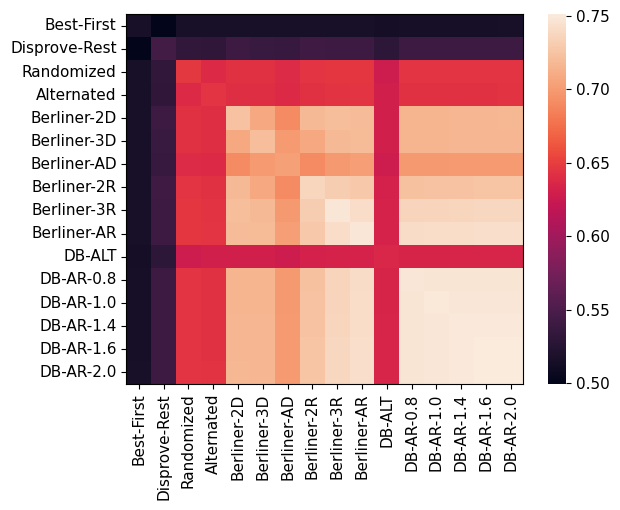

In [113]:
for style in main["style"].unique():
    if "BaseRules" in style: continue
    altm = main[main["style"] == style]
    
    gby = altm[~altm.intractable].groupby('seed')
    pair_counts = {a: {b: (gby[a].any() & gby[b].any()).sum() for b in algos} for a in algos}
    main_pairs = pd.DataFrame(pair_counts)
    del gby, pair_counts
    
    number_of_trees_solved_total = altm[~altm.intractable].groupby('seed').algorithm.count().size
    g = sns.heatmap(main_pairs.loc[algos3, algos3] / altm.seed.unique().size, xticklabels=algos3_labels, yticklabels=algos3_labels)
    g.tick_params(axis='both', which='major', labelsize=11)
    g.collections[0].colorbar.ax.tick_params(labelsize=11)
    # plt.title(f'Fraction of {styledict[style]} Trees Solved per Pair of Algorithms')
    print(f"Overall, {100*number_of_trees_solved_total / altm.seed.unique().size:.1f}% of {styledict[style]} trees are solved by any algorithm.")
    print(f"The best algorithm could solve {100*main_pairs.max().max() / number_of_trees_solved_total:.2f}% of all solved {styledict[style]} trees")
    
    frame_this(g)
    
    plt.savefig(f"../figures/fraction_{styledict[style]}_trees_solved.pdf", format='pdf', bbox_inches='tight')
    plt.show()

Overall, 99.4% of AdjustBefore [g=0.75] trees are solved by any algorithm.
The best algorithm could solve 99.03% of all solved AdjustBefore [g=0.75] trees


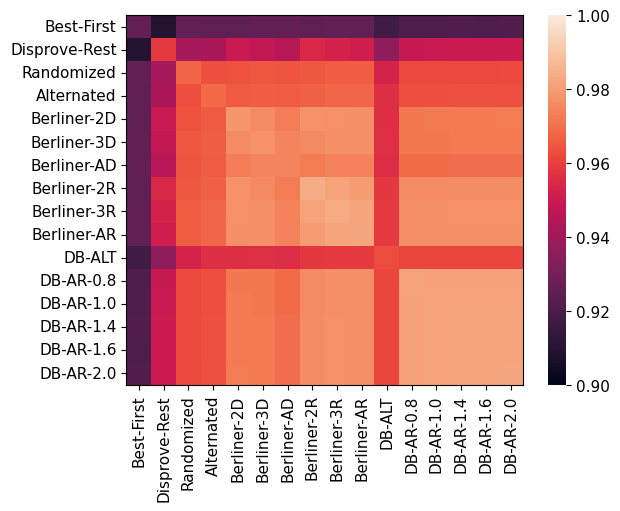

Overall, 100.0% of AdjustAfter [g=0.75] trees are solved by any algorithm.
The best algorithm could solve 99.95% of all solved AdjustAfter [g=0.75] trees


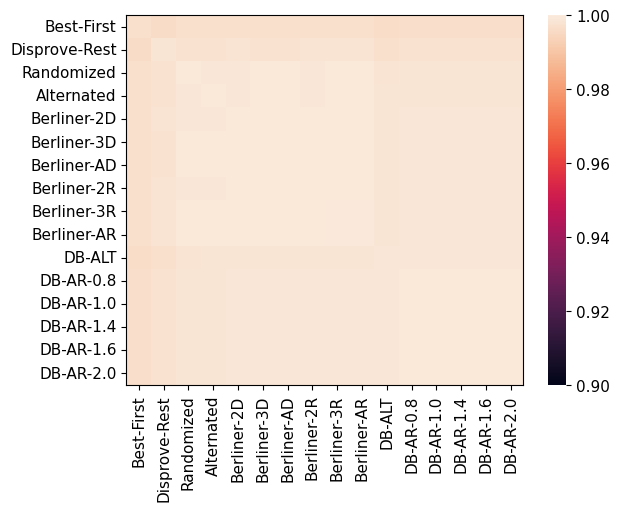

Overall, 80.9% of AdjustBefore [g=1] trees are solved by any algorithm.
The best algorithm could solve 96.83% of all solved AdjustBefore [g=1] trees


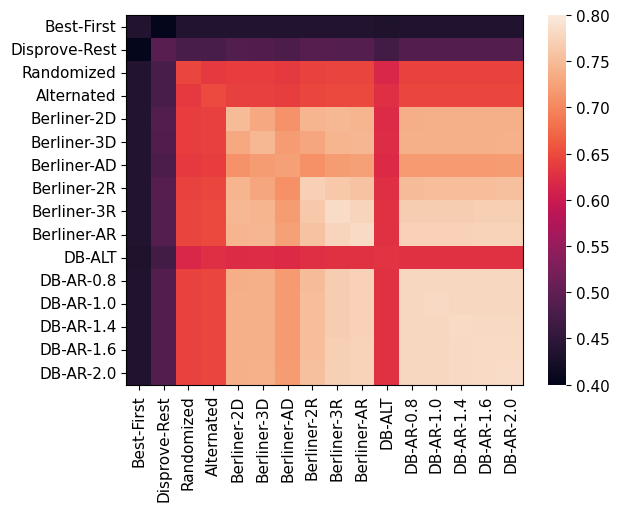

Overall, 81.0% of AdjustAfter [g=1] trees are solved by any algorithm.
The best algorithm could solve 96.84% of all solved AdjustAfter [g=1] trees


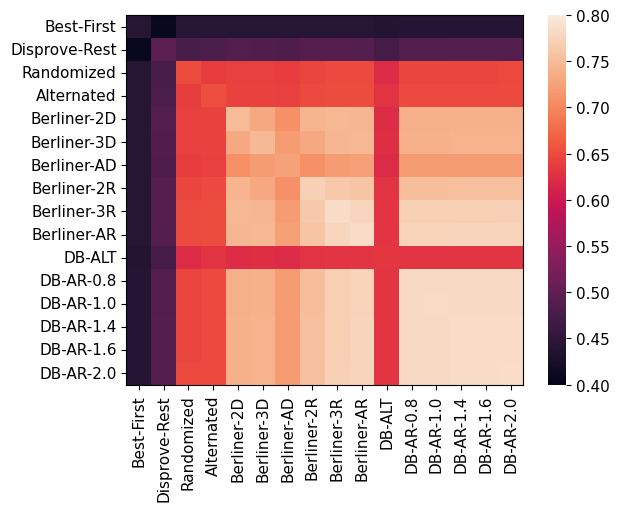

Overall, 43.7% of AdjustBefore [g=1.4] trees are solved by any algorithm.
The best algorithm could solve 97.89% of all solved AdjustBefore [g=1.4] trees


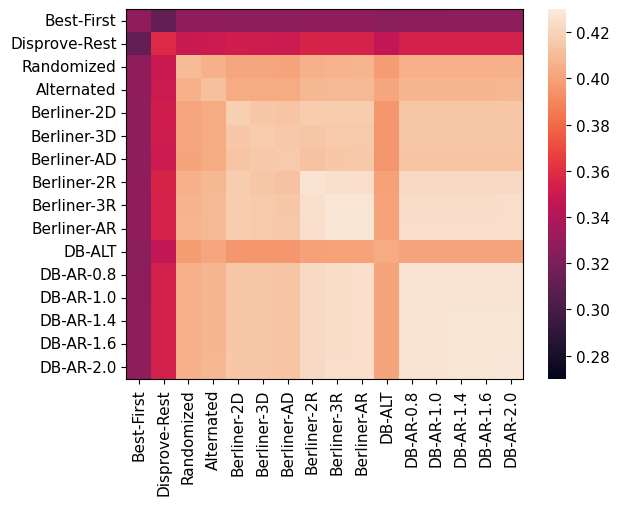

Overall, 38.2% of AdjustAfter [g=1.4] trees are solved by any algorithm.
The best algorithm could solve 97.67% of all solved AdjustAfter [g=1.4] trees


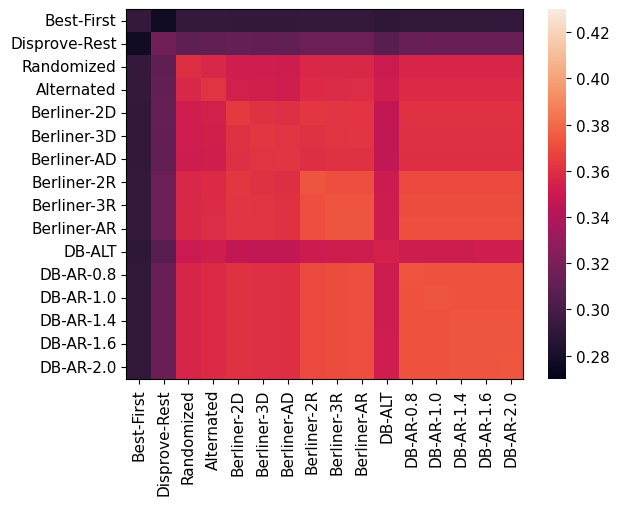

Overall, 43.6% of AdjustBefore [g=2] trees are solved by any algorithm.
The best algorithm could solve 97.29% of all solved AdjustBefore [g=2] trees


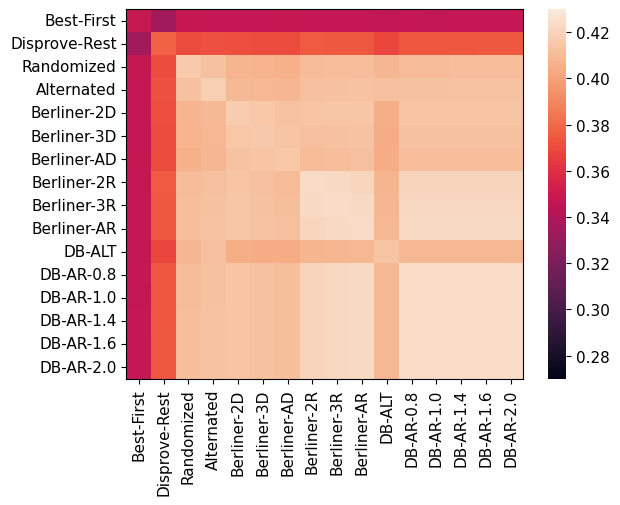

Overall, 41.2% of AdjustAfter [g=2] trees are solved by any algorithm.
The best algorithm could solve 96.99% of all solved AdjustAfter [g=2] trees


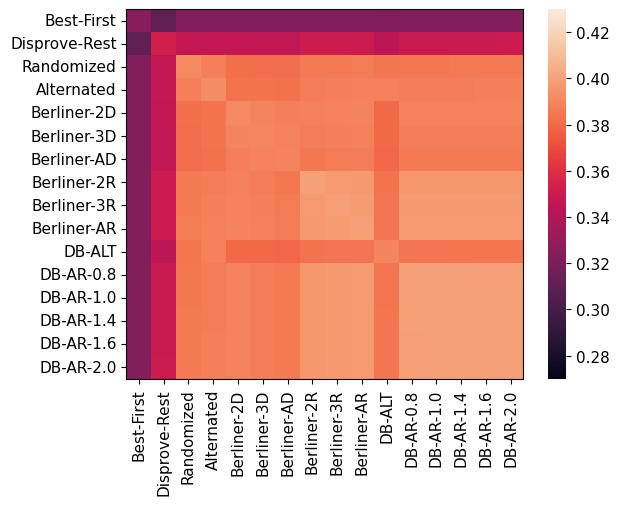

Overall, 75.3% of AdjustBefore [g=3] trees are solved by any algorithm.
The best algorithm could solve 97.29% of all solved AdjustBefore [g=3] trees


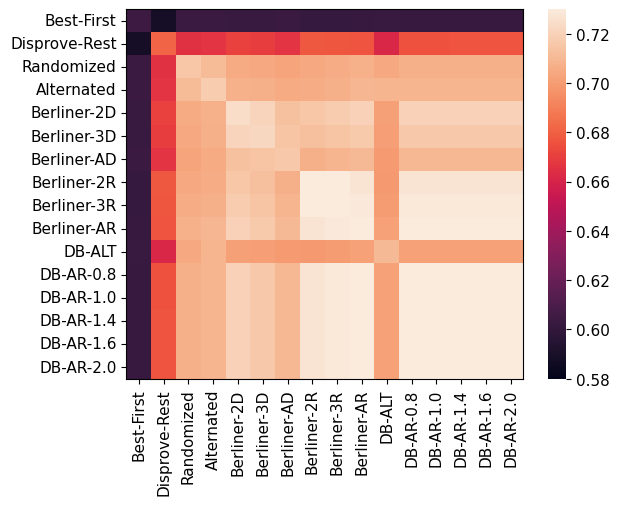

Overall, 74.8% of AdjustAfter [g=3] trees are solved by any algorithm.
The best algorithm could solve 97.03% of all solved AdjustAfter [g=3] trees


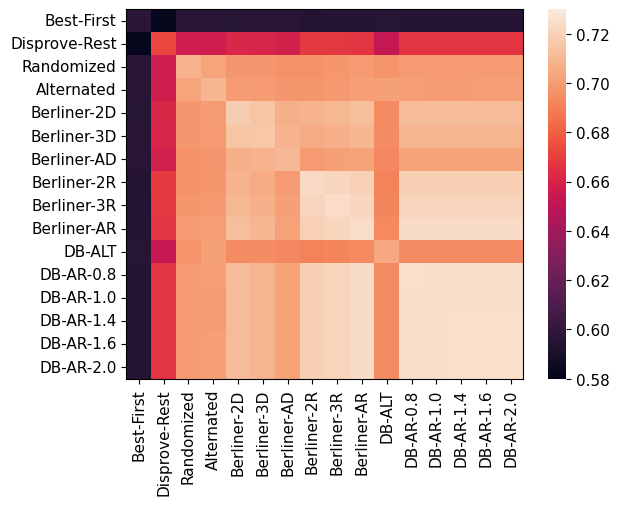

In [114]:
g_names = {0.75 : "0_75", 1: "1_0", 1.4: "1_4", 2: "2_0", 3: "3_0"}
granges = {0.75 : (0.9, 1), 1: (0.4,0.8), 1.4: (0.27,0.43), 2: (0.27,0.43), 3: (0.58,0.73)}

for growth in [0.75, 1, 1.4, 2, 3]:
    for style in ["BaseRulesBefore","BaseRulesAfter"]:
        altm = main[(main["style"] == style) & (main.growth == growth)]

        gby = altm[~altm.intractable].groupby('seed')
        pair_counts = {a: {b: (gby[a].any() & gby[b].any()).sum() for b in algos} for a in algos}
        main_pairs = pd.DataFrame(pair_counts)
        del gby, pair_counts

        number_of_trees_solved_total = altm[~altm.intractable].groupby('seed').algorithm.count().size
        g = sns.heatmap(main_pairs.loc[algos3, algos3] / altm.seed.unique().size, xticklabels=algos3_labels, yticklabels=algos3_labels, vmin=granges[growth][0], vmax=granges[growth][1])
        g.tick_params(axis='both', which='major', labelsize=11)
        g.collections[0].colorbar.ax.tick_params(labelsize=11)
        # plt.title(f'Fraction of {styledict[style]}, $g={growth}$ Trees Solved per Pair of Algorithms')
        print(f"Overall, {100*number_of_trees_solved_total / altm.seed.unique().size:.1f}% of {styledict[style]} [g={growth}] trees are solved by any algorithm.")
        print(f"The best algorithm could solve {100*main_pairs.max().max() / number_of_trees_solved_total:.2f}% of all solved {styledict[style]} [g={growth}] trees")

        frame_this(g)

        plt.savefig(f"../figures/fraction_{styledict[style]}_{g_names[growth]}_trees_solved.pdf", format='pdf', bbox_inches='tight')
        plt.show()

In [22]:
# NOT USING THESE

# # THIS COULD BE A TABLE INSTEAD
# for style in main["style"].unique():
#     temp = main[main["style"] == style]
#     algo_select = algos3 #[alg for alg in algos3 if "DB-Ar" in alg or ("berlin-" in alg and "Ar" in alg) or ("berlin-" in alg and "3r" in alg)]
#     ys = [temp[temp.algorithm == alg].intractable.sum()for alg in algo_select]
#     plt.bar(algo_select, ys)
#     plt.xticks(rotation=45, ha='right')
#     plt.title(f"Number of intractable for {styledict[style]} trees")
#     plt.show()

In [23]:
# NOT USING THIS ONE

# g = sns.heatmap(main.groupby(['width','num_alts']).intractable.sum().unstack(level=1).loc[range(10,2,-1)], cmap="Reds", vmin=0)
# frame_this(g)
# plt.xlabel("Tree Parameter $k$")
# plt.ylabel("Branching Factor $b$")
# plt.title("Number of Intractable Trees by Tree Parameters");

In [24]:
# NOT USING THIS ONE

# g = sns.heatmap(main.groupby(['style','num_alts']).intractable.sum().unstack(level=1).reindex(index=styleorder), cmap="Reds", vmin=0, yticklabels=stylelabels)
# frame_this(g)
# plt.xlabel("Tree Parameter $k$")
# plt.ylabel("Generation Style")
# plt.title("Number of Intractable Trees by Tree Parameters");

In [25]:
# NOT USING THIS ONE

# g = sns.heatmap(main.groupby(['width','range']).intractable.sum().unstack(level=1).loc[range(10,2,-1)], cmap="Reds", vmin=0)
# frame_this(g)
# plt.xlabel("$R$: Initial Range of Values at the Root Node")
# plt.ylabel("Branching Factor $b$")
# plt.title("Number of Intractable Trees by Tree Parameters");

In [26]:
# NOT USING THIS ONE

# g = sns.heatmap(main.groupby(['width','growth']).intractable.sum().unstack(level=1).loc[range(10,2,-1)], cmap="Reds", vmin=0)
# frame_this(g)
# plt.xlabel("Growth Factor $g$")
# plt.ylabel("Branching Factor $b$")
# plt.title("Number of Intractable Trees by Tree Parameters");

In [27]:
# NOT USING THIS ONE

# growths = list(main.growth.unique())
# g = sns.heatmap(main.groupby(['growth','num_alts']).intractable.sum().unstack(level=1).loc[sorted(growths, reverse=True)], cmap="Reds", vmin=0)
# frame_this(g)
# plt.ylabel("Growth Factor $g$")
# plt.xlabel("Tree Parameter $k$")
# plt.title("Number of Intractable Trees by Tree Parameters");

D:\Users\anema\Anaconda3\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical left == right == 0 results in singular transformations; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
D:\Users\anema\Anaconda3\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical bottom == top == 0 results in singular transformations; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


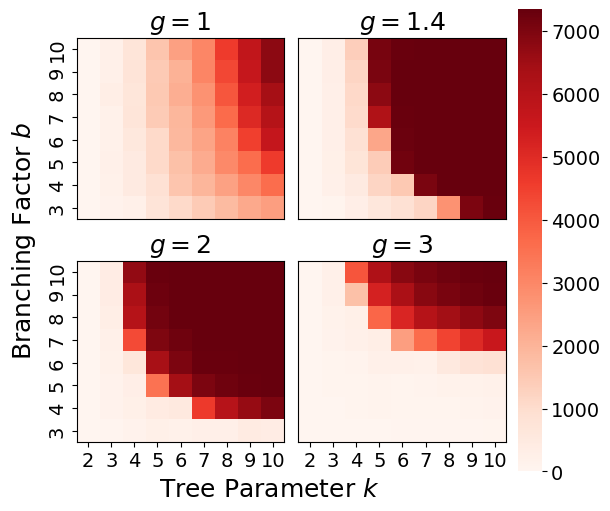

In [66]:
fig = plt.figure(layout='constrained', figsize=(6,5))

ax1 = plt.subplot2grid((13,29), (0,2), 6,11)
ax2 = plt.subplot2grid((13,29), (0,13), 6,11)
ax3 = plt.subplot2grid((13,29), (6,2), 6,11)
ax4 = plt.subplot2grid((13,29), (6,13), 6,11)

axs = [ax1, ax2, ax3, ax4]
growths = [1, 1.4, 2, 3]
pre_dfs = [main[(main.growth == growths[i]) & ((main["style"] == "BaseRulesBefore") | (main["style"] == "BaseRulesBefore"))] for i in range(4)]
dfs = [pre_dfs[i].groupby(['width','num_alts']).intractable.sum().unstack(level=1).loc[range(10,2,-1)] for i in range(4)]
vmax = max([df.max().max() for df in dfs])

for i in range(4):
    sns.heatmap(dfs[i], cmap="Reds", vmin=0, vmax=vmax, ax=axs[i], cbar=False)
    axs[i].set_xlabel(None)
    axs[i].set_ylabel(None)
    axs[i].tick_params(axis='both', which='major', labelsize=14)
    axs[i].set_title(f"$g = {growths[i]}$", fontsize=18)
    
ax1.set_xticks([])
ax2.set_xticks([])
ax2.set_yticks([])
ax4.set_yticks([])

for ax in axs: frame_this(ax)
    
ax0 = fig.add_subplot(111, frameon=False)
# ax0.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
sns.heatmap(pd.DataFrame({}), cmap="Reds", vmin=0, vmax=vmax, ax=ax0)
ax0.set_xlabel("Tree Parameter $k$", fontsize=18)
ax0.set_ylabel("Branching Factor $b$", fontsize=18)
ax0.collections[0].colorbar.ax.tick_params(labelsize=14)

# plt.suptitle("Number of Intractable Trees by Growth Factor $g$");
plt.savefig(f"../figures/number_of_intracrable_by_growth.pdf", format='pdf', bbox_inches='tight');

D:\Users\anema\Anaconda3\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical left == right == 0 results in singular transformations; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
D:\Users\anema\Anaconda3\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical bottom == top == 0 results in singular transformations; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


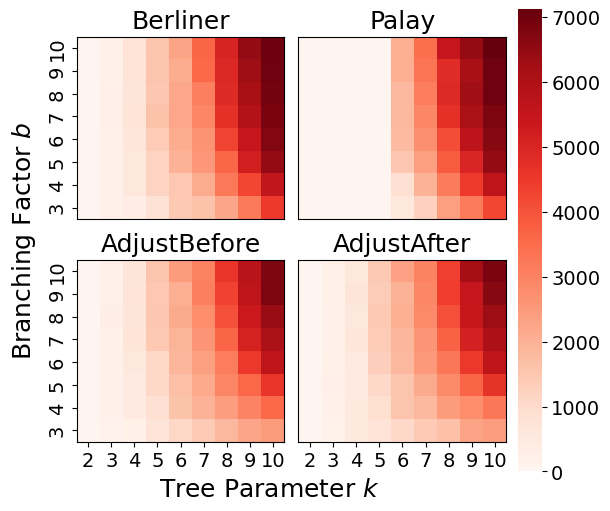

In [65]:
fig = plt.figure(layout='constrained', figsize=(6,5))

ax1 = plt.subplot2grid((13,29), (0,2), 6,11)
ax2 = plt.subplot2grid((13,29), (0,13), 6,11)
ax3 = plt.subplot2grid((13,29), (6,2), 6,11)
ax4 = plt.subplot2grid((13,29), (6,13), 6,11)

axs = [ax1, ax2, ax3, ax4]
pre_dfs = [main[(main.growth == 1) & (main["style"] == styleorder[i])] for i in range(4)]
dfs = [pre_dfs[i].groupby(['width','num_alts']).intractable.sum().unstack(level=1).loc[range(10,2,-1)] for i in range(4)]
vmax = max([df.max().max() for df in dfs])

for i in range(4):
    sns.heatmap(dfs[i], cmap="Reds", vmin=0, vmax=vmax, ax=axs[i], cbar=False)
    axs[i].set_xlabel(None)
    axs[i].set_ylabel(None)
    axs[i].tick_params(axis='both', which='major', labelsize=14)
    axs[i].set_title(f"{stylelabels[i]}", fontsize=18)
    
ax1.set_xticks([])
ax2.set_xticks([])
ax2.set_yticks([])
ax4.set_yticks([])

for ax in axs: frame_this(ax)
    
ax0 = fig.add_subplot(111, frameon=False)
# ax0.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
sns.heatmap(pd.DataFrame({}), cmap="Reds", vmin=0, vmax=vmax, ax=ax0)
ax0.set_xlabel("Tree Parameter $k$", fontsize=18)
ax0.set_ylabel("Branching Factor $b$", fontsize=18)
ax0.collections[0].colorbar.ax.tick_params(labelsize=14)

# plt.suptitle("Number of Intractable Trees by Generation Style with $g=1$")
plt.savefig(f"../figures/number_of_intracrable_by_style.pdf", format='pdf', bbox_inches='tight');

In [21]:
# NOT USING THIS ONE

# g = sns.heatmap(main[main.growth == 0.75].groupby(['width','num_alts']).intractable.sum().unstack(level=1).loc[range(10,2,-1)], cmap="Reds", vmin=0)
# frame_this(g)
# plt.xlabel("Tree Parameter $k$")
# plt.ylabel("Number of Moves per Turn")
# plt.title("Number of Intractable Trees for $g=0.75$");

In [22]:
# NO LONGER USING THESE

# sns.barplot(main_all, x="num_alts", y="evaluated", hue="algorithm", hue_order=algos3, errorbar=None)
# plt.title("Effort expended on problems solved by all")
# plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
# plt.show()
# sns.barplot(main_all, x="num_alts", y="seconds", hue="algorithm", hue_order=algos3, errorbar=None)
# plt.title("Time spent on problems solved by all")
# plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left");

In [23]:
# NO LONGER USING THESE

# sns.barplot(main_all, x="width", y="evaluated", hue="algorithm", hue_order=algos3, errorbar=None)
# plt.title("Effort expended on problems solved by all")
# plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
# plt.show()
# sns.barplot(main_all, x="width", y="seconds", hue="algorithm", hue_order=algos3, errorbar=None)
# plt.title("Time spent on problems solved by all")
# plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left");

In [24]:
# NO LONGER USING THESE

# for style in main_none['style'].unique():
#     sns.barplot(main_none[main_none["style"] == style], x="num_alts", y="distance", hue="algorithm", hue_order=algos3, errorbar=None)
#     plt.title(f"Progress made on the most difficult problems - {style}")
#     plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
#     plt.show()
#     # sns.barplot(main_none[main_none["style"] == style], x="num_alts", y="seconds", hue="algorithm", hue_order=algos3, errorbar=None)
#     # plt.title("Time spent on the most difficult problems")
#     # plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left");

## Examine interesting patterns

In [94]:
def get_buckets(data, use_intractable=False, use_unsolved=False):
    df = data.copy()
    df["treesize"] = 0
    df.loc[df.algorithm == "always-PB", "treesize"] = df.loc[df.algorithm == "always-PB", "evaluated"]
    df.loc[:, "treesize"] = df.groupby('seed')["treesize"].transform("max")

    df["bucket"] = ">15000"
    df.loc[df.treesize <= 15000, "bucket"] = "5000-15000"
    df.loc[df.treesize <= 5000, "bucket"] = "1500-5000"
    df.loc[df.treesize <= 1500, "bucket"] = "<1500"
    # df.loc[df.treesize <= 1000, "bucket"] = "<1000"
    # df.loc[df.treesize <= 200, "bucket"] = "<200"
    # df.loc[df.treesize == 500000, "bucket"] = "intractable"
    # df.loc[df.groupby('seed').intractable.transform("any"), "bucket"] = "intractable"
    # df.loc[df.groupby('seed').intractable.transform("all"), "bucket"] = "unsolved"
    # bucket_order = ["<200", "<1000", "<5000", "<15000", ">15000"]
    bucket_order = ["1500-5000", "5000-15000", ">15000"]
    if use_intractable or use_unsolved:
        df.loc[df.groupby('seed').intractable.transform("any"), "bucket"] = "intractable"
        df.loc[df.groupby('seed').intractable.transform("all"), "bucket"] = "unsolved"
        bucket_order = ["<200", "<1000", "<5000", "<15000", ">15000", "intractable"]
    if use_unsolved: bucket_order += ["unsolved"]
    return df, bucket_order

C:\Users\anema\AppData\Local\Temp\ipykernel_19936\3036471387.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(df, x="num_alts", y="P2MA", errorbar=('ci', 95), palette='twilight_shifted')


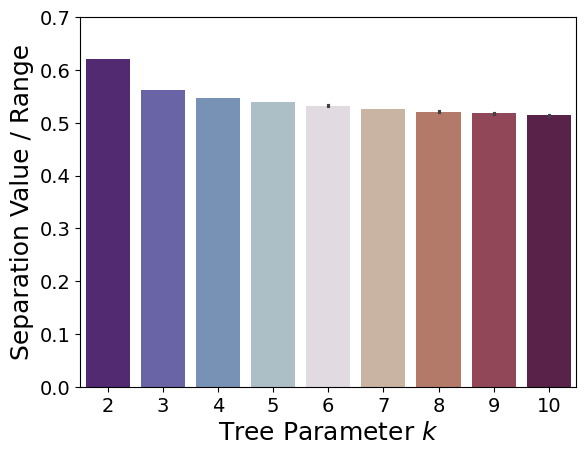

C:\Users\anema\AppData\Local\Temp\ipykernel_19936\3036471387.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(df, x="width", y="P2MA", errorbar=('ci', 95), palette='twilight_shifted')


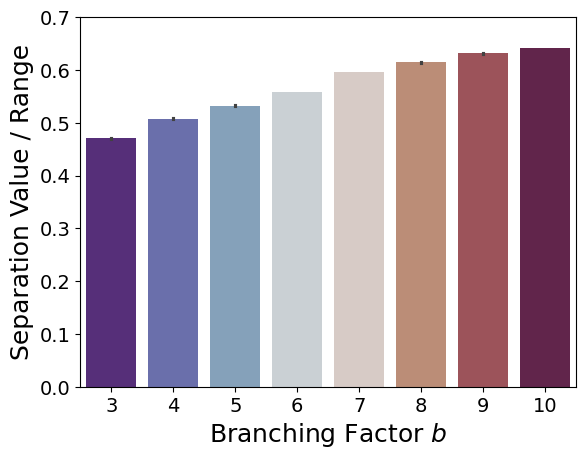

C:\Users\anema\AppData\Local\Temp\ipykernel_19936\3036471387.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(df, x="growth", y="P2MA", errorbar=('ci', 95), palette='twilight_shifted')


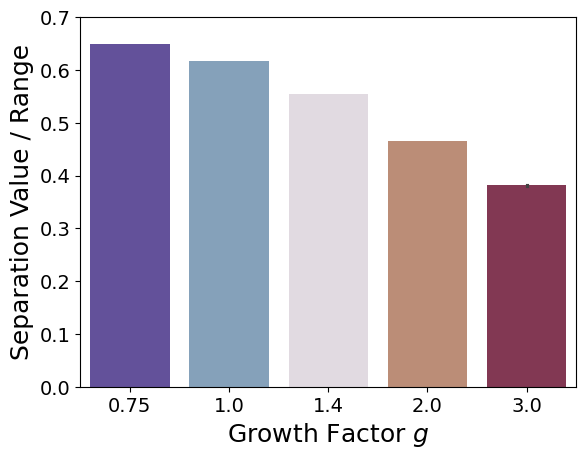

C:\Users\anema\AppData\Local\Temp\ipykernel_19936\3036471387.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(df, x="bucket", y="P2MA", order=bucket_order, errorbar=('ci', 95), palette='twilight_shifted')


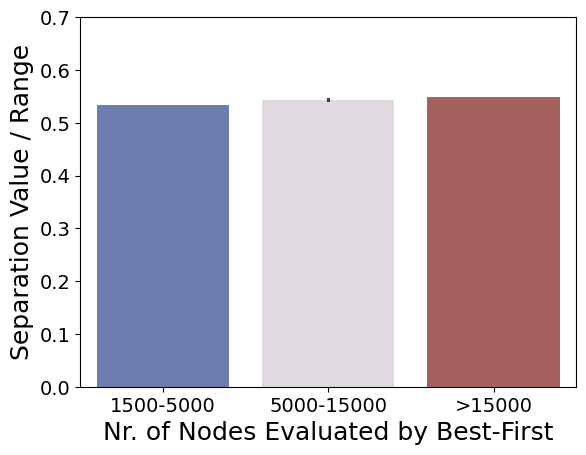

In [95]:
df, bucket_order = get_buckets(main_all)
# display(df.bucket.value_counts().loc[bucket_order])

df["P2MA"] = df.sepValue / df.range
g = sns.barplot(df, x="num_alts", y="P2MA", errorbar=('ci', 95), palette='twilight_shifted')
g.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel("Tree Parameter $k$", fontsize=18)
plt.ylabel("Separation Value / Range", fontsize=18)
# plt.title("Parameter $k$ Effects on Minimum Score")
plt.ylim((0,0.7))
plt.savefig(f"../figures/distance_by_num_alts.pdf", format='pdf', bbox_inches='tight')
plt.show()

g = sns.barplot(df, x="width", y="P2MA", errorbar=('ci', 95), palette='twilight_shifted')
g.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel("Branching Factor $b$", fontsize=18)
plt.ylabel("Separation Value / Range", fontsize=18)
# plt.title("Branching Factor Effects on Minimum Score")
plt.ylim((0,0.7))
plt.savefig(f"../figures/distance_by_branching_factor.pdf", format='pdf', bbox_inches='tight')
plt.show()

g = sns.barplot(df, x="growth", y="P2MA", errorbar=('ci', 95), palette='twilight_shifted')
g.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel("Growth Factor $g$", fontsize=18)
plt.ylabel("Separation Value / Range", fontsize=18)
# plt.title("Growth Factor Effects on Minimum Score")
plt.ylim((0,0.7))
plt.savefig(f"../figures/distance_by_growths.pdf", format='pdf', bbox_inches='tight')
plt.show()

g = sns.barplot(df, x="bucket", y="P2MA", order=bucket_order, errorbar=('ci', 95), palette='twilight_shifted')
g.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel("Nr. of Nodes Evaluated by Best-First", fontsize=18)
plt.ylabel("Separation Value / Range", fontsize=18)
# plt.title("No Relation between Tree Size and Minimum Score")
plt.ylim((0,0.7))
plt.savefig(f"../figures/distance_by_treesize.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [68]:
main_buckets, bucket_order2 = get_buckets(main, use_intractable=False)

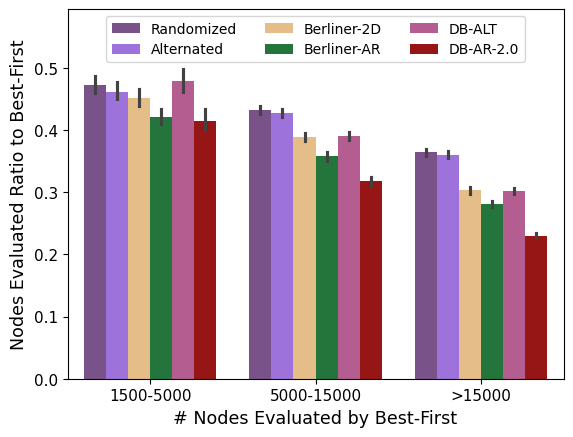

In [87]:
# TODO: it is probably incorrect how I have filtered out the intractables here...
#  ---- the buckets should at least be aggregating all the same trees for all algorithms (!)
algo_select_ = ["randomize","alternate","berlin-2D","berlin-AR","altern-DB","DB-AR-2.0"]
algo_select = [algos3dict[x] for x in algo_select_]
palette = {algos3dict[alg]: algorithm_colors[alg] for alg in algo_select_}
# palette["Berliner-2D"] = "#249c47"
dff = main_buckets[main_buckets.algorithm.isin(algo_select_)].copy()
dff.loc[:, "algorithm"] = dff.algorithm.replace(algos3dict)
dff = dff[(~dff.intractable)]
dff["ratio"] = dff.evaluated / dff.treesize
g = sns.barplot(dff, x="bucket", y="ratio", errorbar=('ci', 95), order=bucket_order2, hue="algorithm", hue_order=algo_select, palette=palette)
# plt.legend(loc="upper right")
# plt.title("Effort Required for solving problems")
plt.xlabel("# Nodes Evaluated by Best-First", fontsize=12.6)
plt.ylabel("Nodes Evaluated Ratio to Best-First", fontsize=12.6)
plt.ylim((0,0.595))
g.tick_params(axis='both', which='major', labelsize=11)
plt.legend(prop={'size':10}, loc="upper center", ncol=3)
# plt.legend(prop={'size':10}, bbox_to_anchor=(1, 1.021))
plt.savefig(f"../figures/nodes_evaluated_by_size.pdf", format='pdf', bbox_inches='tight');

In [52]:
none_bf_ratios = main_none.copy()
none_bf_ratios["BF_distance"] = 0
none_bf_ratios.loc[none_bf_ratios.algorithm == "always-PB", "BF_distance"] = none_bf_ratios.loc[none_bf_ratios.algorithm == "always-PB", "distance"]
none_bf_ratios.loc[:, "BF_distance"] = none_bf_ratios.groupby('seed')["BF_distance"].transform("max")
none_bf_ratios["distance_ratio"] = none_bf_ratios.distance / none_bf_ratios.BF_distance
none_bf_ratios["distance_diff"] = none_bf_ratios.distance - none_bf_ratios.BF_distance
none_bf_ratios = none_bf_ratios.replace(algos3dict)

C:\Users\anema\AppData\Local\Temp\ipykernel_19936\474624689.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(none_bf_ratios2[none_bf_ratios2.BF_distance >= 0.2], x="algorithm", y="distance_ratio", errorbar=('ci', 95), order=algo_order, palette=palette)


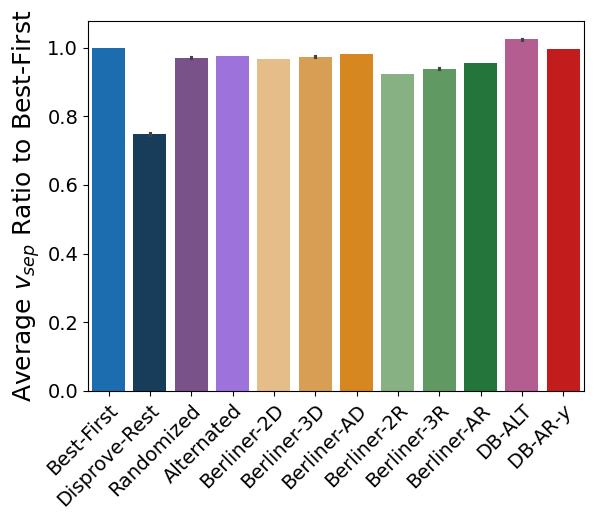

C:\Users\anema\AppData\Local\Temp\ipykernel_19936\474624689.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(none_bf_ratios2[none_bf_ratios2.BF_distance < 0.2], x="algorithm", y="distance_ratio", errorbar=('ci', 95), order=algo_order, palette=palette)


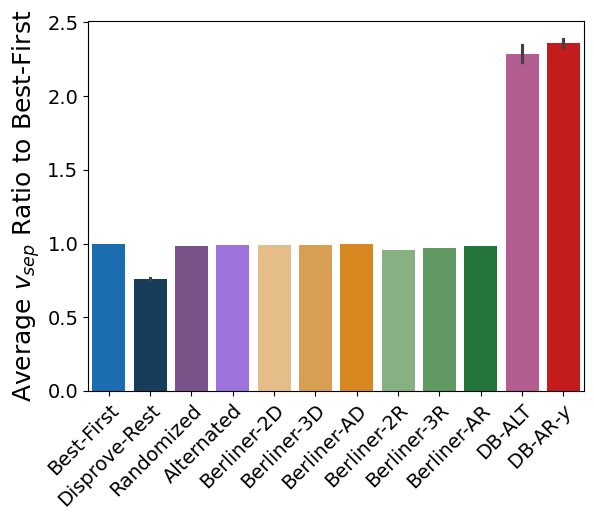

C:\Users\anema\AppData\Local\Temp\ipykernel_19936\474624689.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(none_bf_ratios2, x="algorithm", y="distance_diff", errorbar=('ci', 95), order=algo_order, palette=palette)


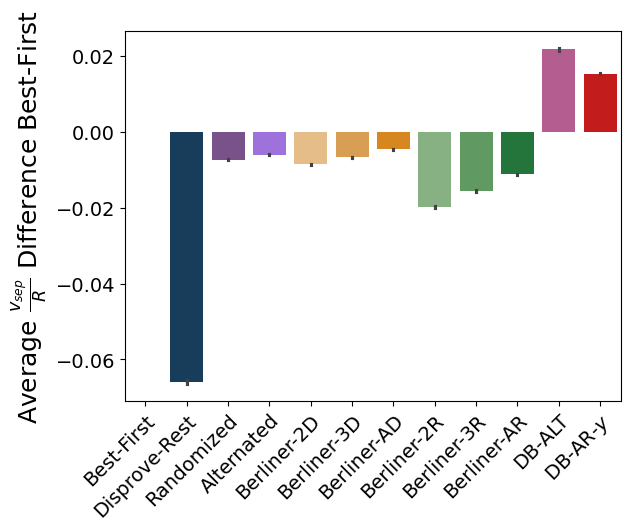

C:\Users\anema\AppData\Local\Temp\ipykernel_19936\474624689.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(none_bf_ratios2, x="algorithm", y="distance", errorbar=('ci', 95), order=algo_order, palette=palette)


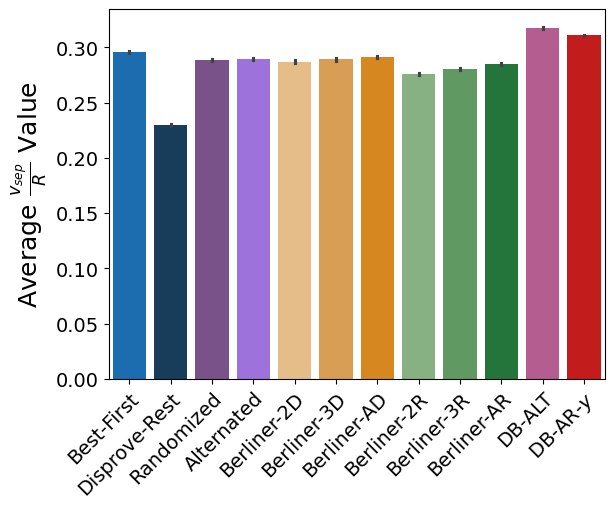

In [91]:
groupname = "DB-AR-$y$"
algorithms = [algo for algo in algos3 if not algo in ["DB-AR-0.8","DB-AR-1.0","DB-AR-1.4","DB-AR-1.6"]]
dbarold, algorithm_colors["DB-AR-2.0"] = algorithm_colors["DB-AR-2.0"], "#de0000"
palette = [algorithm_colors[alg] for alg in algorithms]
algorithm_colors["DB-AR-2.0"] = dbarold
algo_order = [algos3dict[a] for a in algorithms if not a == "DB-AR-2.0"] + [groupname]
none_bf_ratios2 = none_bf_ratios
for alg in ["DB-AR-0.8","DB-AR-1.0","DB-AR-1.4","DB-AR-1.6","DB-AR-2.0"]:
    none_bf_ratios2 = none_bf_ratios2.replace({alg : groupname})
g = sns.barplot(none_bf_ratios2[none_bf_ratios2.BF_distance >= 0.2], x="algorithm", y="distance_ratio", errorbar=('ci', 95), order=algo_order, palette=palette)
# plt.xlabel("Tree Search Algorithm", fontsize=18)
plt.xlabel(None)
plt.ylabel("Average $v_{sep}$ Ratio to Best-First", fontsize=18)
# plt.suptitle("Progress Made on Unsolved Trees")
# plt.title("(where Best-First achieved at least 0.2)")
plt.xticks(rotation=45, ha='right', rotation_mode="anchor")
g.tick_params(axis='both', which='major', labelsize=14)
plt.savefig(f"../figures/progress_unsolved_ratio_highBF.pdf", format='pdf', bbox_inches='tight');
plt.show()

g = sns.barplot(none_bf_ratios2[none_bf_ratios2.BF_distance < 0.2], x="algorithm", y="distance_ratio", errorbar=('ci', 95), order=algo_order, palette=palette)
# plt.xlabel("Tree Search Algorithm", fontsize=18)
plt.xlabel(None)
plt.ylabel("Average $v_{sep}$ Ratio to Best-First", fontsize=18)
# plt.suptitle("Progress Made on Unsolved Trees")
# plt.title("(where Best-First achieved at most 0.2)")
plt.xticks(rotation=45, ha='right', rotation_mode="anchor")
g.tick_params(axis='both', which='major', labelsize=14)
plt.savefig(f"../figures/progress_unsolved_ratio_lowBF.pdf", format='pdf', bbox_inches='tight');
plt.show()

g = sns.barplot(none_bf_ratios2, x="algorithm", y="distance_diff", errorbar=('ci', 95), order=algo_order, palette=palette)
# plt.xlabel("Tree Search Algorithm", fontsize=18)
plt.xlabel(None)
plt.ylabel("Average $\\frac{v_{sep}}{R}$ Difference Best-First", fontsize=18)
# plt.title("Progress Made on Unsolved Trees")
plt.xticks(rotation=45, ha='right', rotation_mode="anchor")
g.tick_params(axis='both', which='major', labelsize=14)
plt.savefig(f"../figures/progress_unsolved_diff_BF.pdf", format='pdf', bbox_inches='tight');
plt.show()

g = sns.barplot(none_bf_ratios2, x="algorithm", y="distance", errorbar=('ci', 95), order=algo_order, palette=palette)
# plt.xlabel("Tree Search Algorithm", fontsize=18)
plt.xlabel(None)
plt.ylabel("Average $\\frac{v_{sep}}{R}$ Value", fontsize=18)
# plt.title("Progress Made on Unsolved Trees")
plt.xticks(rotation=45, ha='right', rotation_mode="anchor")
g.tick_params(axis='both', which='major', labelsize=14)
plt.savefig(f"../figures/progress_unsolved_value.pdf", format='pdf', bbox_inches='tight');

In [57]:
def get_data_ratios(filtered, algorithms, metric, interval=None):
    __ = slice(None)
    data = filtered.groupby(['seed','algorithm']).first().loc[(__,algorithms),:]
    BF = filtered[filtered.algorithm == "always-PB"].groupby('seed').first()
    data["ratio"] = None
    data["treesize"] = None
    for alg in algorithms:
        if alg == "always-PB": continue
        data.loc[(__,alg), "ratio"] = data.loc[(__,alg), metric] / BF.loc[:, metric]
        if interval is not None:
            data.loc[(__,alg), "treesize"] = round((data.loc[(__,alg), metric] + BF.loc[:, metric] - data.loc[(__,alg), metric]) / interval) * interval
        else:
            data.loc[(__,alg), "treesize"] = data.loc[(__,alg), metric] + BF.loc[:, metric] - data.loc[(__,alg), metric]
    data = data.reset_index()
    data.ratio = data.ratio.astype(float)
    data.treesize = data.treesize.astype(data[metric].dtype)
    return data

def pointplot(filtered, algorithms, metric, interval, max_tree_size, max_ratio_prune, y_axis="ratio", native_scale=False, **kwargs):
    fig, ax = plt.subplots(figsize=(6, 6))
    palette = [algorithm_colors[alg] for alg in algorithms]
    algo_order = [algos3dict[a] for a in algorithms]
    
    data = get_data_ratios(filtered, algorithms, metric, interval)
    data.treesize = data.treesize.astype(int)
    data = data.replace(algos3dict).rename(columns={"algorithm":"Algorithm"})
    ax = sns.pointplot(data[(data.treesize <= max_tree_size) & (data.ratio <= max_ratio_prune)], x="treesize", y=y_axis, hue="Algorithm", hue_order=algo_order, palette=palette, ax=ax, native_scale=native_scale, **kwargs)
    if native_scale:
        ax.set_xticks(np.linspace(0, max_tree_size, 7))
    else:
        ax.set_xticks(range(0,max_tree_size//interval+1,(max_tree_size//interval)//6))
    # ax.legend(bbox_to_anchor=(1.3, 1))
    return ax

def lineplot(filtered, algorithms, metric, num_groups, max_tree_size, max_ratio_prune, grouping='median', errorbar=None, y_axis="ratio"):
    palette = [algorithm_colors[alg] for alg in algorithms]
    algo_order = [algos3dict[a] for a in algorithms]
    
    data = get_data_ratios(filtered, algorithms, metric)
    data_f = data[(data.ratio <= max_ratio_prune) & (data.treesize <= max_tree_size)].sort_values('treesize').copy()
    data_f['group'] = [x // (len(data_f) // (num_groups+1)) for x in range(len(data_f))]
    data_f.treesize = data_f.groupby('group').treesize.transform(grouping)
    data_f = data_f[data_f["group"] <= num_groups]
    data_f = data_f.replace(algos3dict).rename(columns={"algorithm":"Algorithm"})
    ax = sns.lineplot(data_f, x="treesize", y=y_axis, hue="Algorithm", hue_order=algo_order, palette=palette, errorbar=errorbar)
    # ax.legend(bbox_to_anchor=(1.3, 1))
    return ax

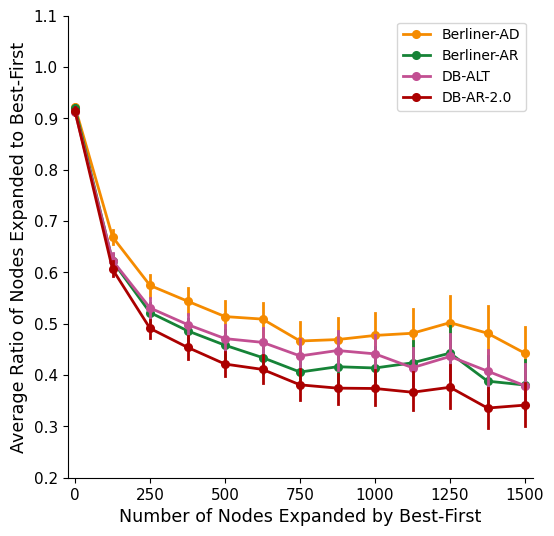

In [64]:
algorithms = ["berlin-AD", "berlin-AR", "altern-DB", "DB-AR-2.0"]
ax = pointplot(main_all[(main_all["style"] == "Palay")], algorithms, "expanded", 125, 1500, 3, native_scale=True, linewidth=2)
# ax.set_xticks(np.linspace(0,1500,7))
ax.set_yticks(np.linspace(0.2,1.1,10))
ax.set_ylim((0.2,1.1))
ax.set_xlim((-25,1525))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.ylim((0,1.125))
ax.tick_params(axis='both', which='major', labelsize=11)
plt.xlabel("Number of Nodes Expanded by Best-First", fontsize=12.6)
plt.ylabel("Average Ratio of Nodes Expanded to Best-First", fontsize=12.6)
plt.legend(prop={'size':10}, loc="upper right")
# plt.title(f"Nodes Expanded Ratio on Palay Trees")
plt.savefig(f"../figures/nodes_expanded_ratio_palay.pdf", format='pdf', bbox_inches='tight');
plt.show()

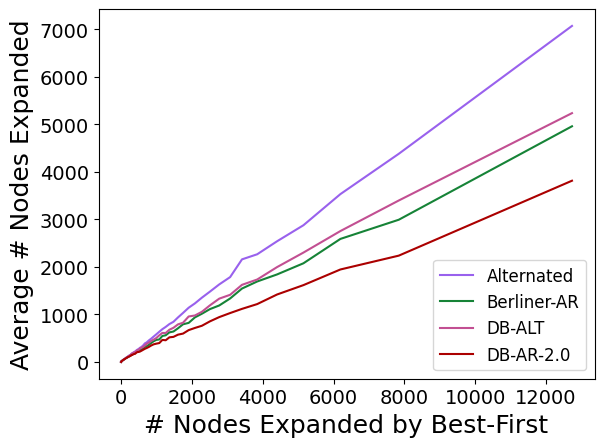

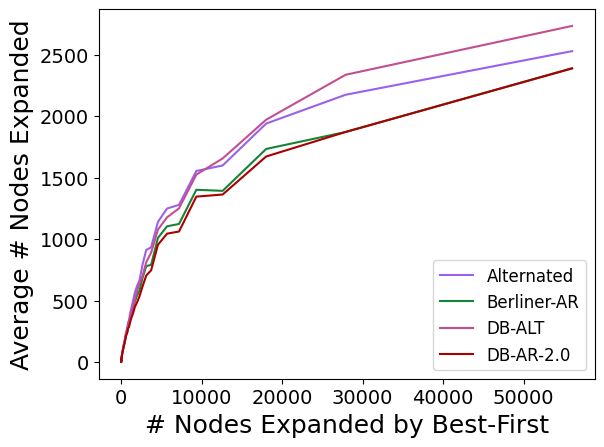

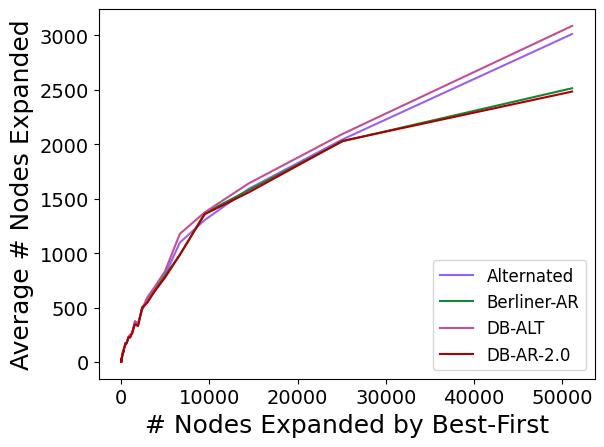

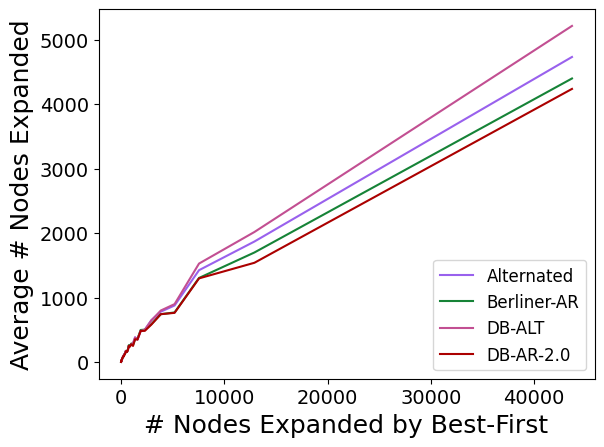

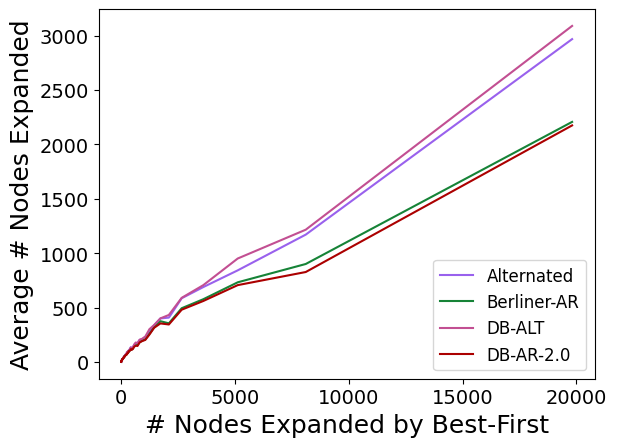

In [66]:
def absolute_plot(algorithms, styles, max_size, growth):
    ax = lineplot(main_all[(main_all["style"].isin(styles)) & (main_all.growth == growth)], algorithms, "expanded", 100, max_size, 3, "mean", y_axis="expanded")
    plt.xlabel("# Nodes Expanded by Best-First", fontsize=18)
    plt.ylabel("Average # Nodes Expanded", fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=14)
    plt.legend(prop={'size': 12}, loc="lower right")
    # plt.title(f"Nodes Expanded on large $g={growth}$ Trees")

algorithms = ["alternate", "berlin-AR", "altern-DB", "DB-AR-2.0"]
styles = ["Berliner", "Palay", "BaseRulesBefore","BaseRulesAfter"]
growths = [0.75, 1, 1.4, 2, 3]
max_size = 1000000000
g_names = {0.75:"0_75",1:"1_0",1.4:"1_4",2:"2_0",3:"3_0"}

for growth in growths:
    absolute_plot(algorithms, styles, max_size, growth)
    plt.savefig(f"../figures/abs_nodes_expanded_{g_names[growth]}.pdf", format='pdf', bbox_inches='tight');
    plt.show()

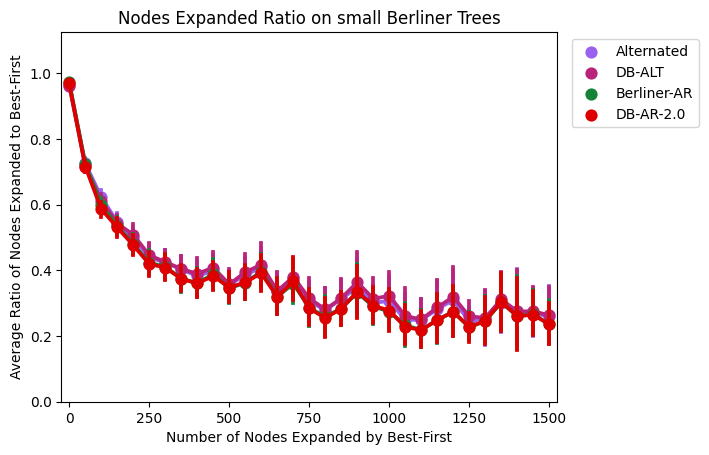

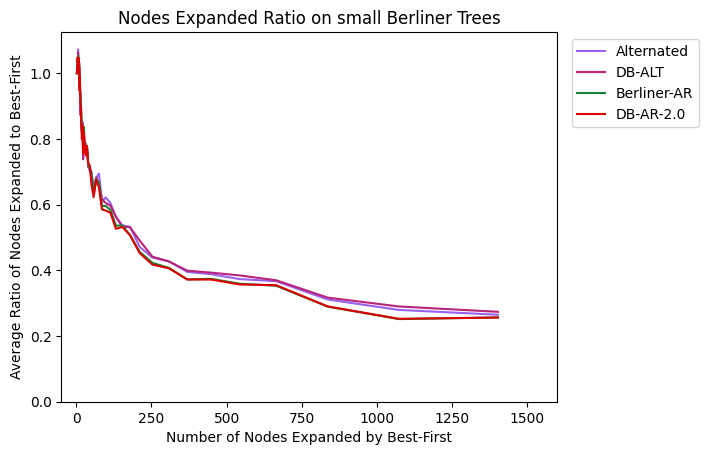

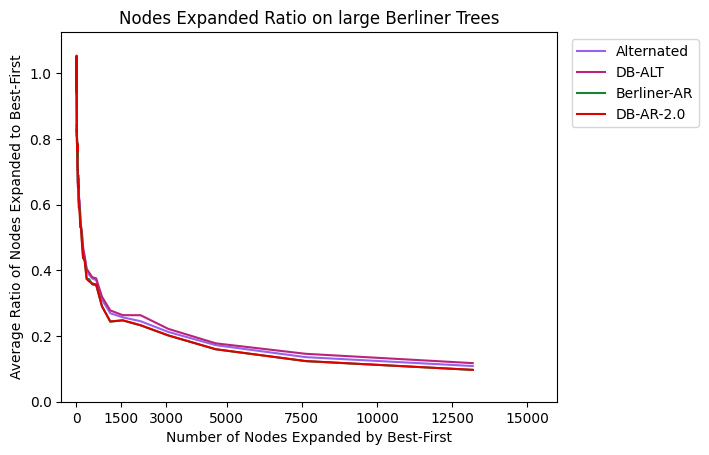

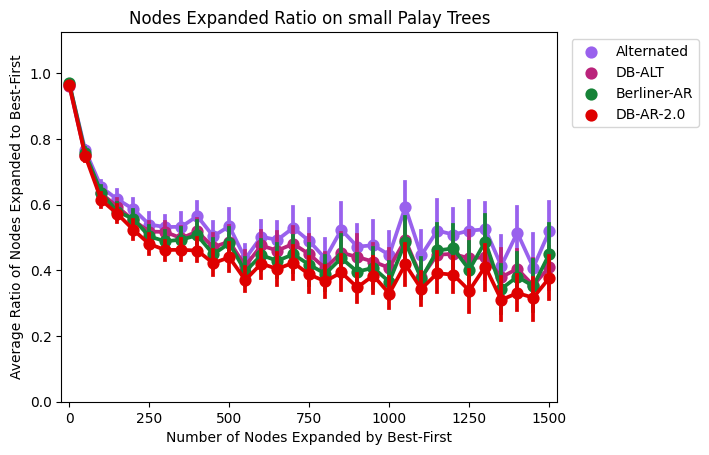

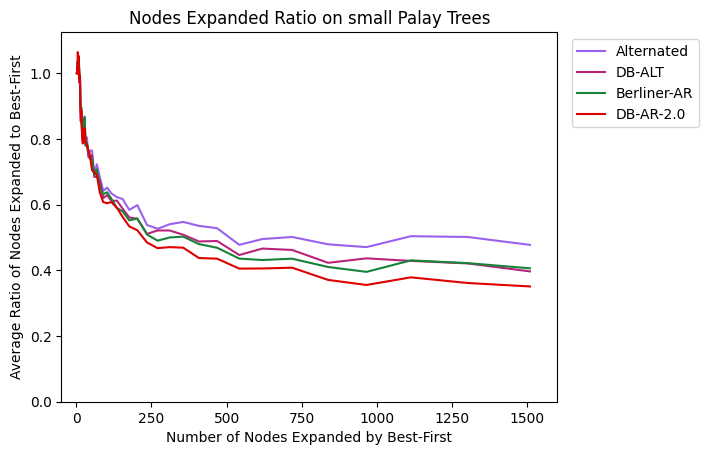

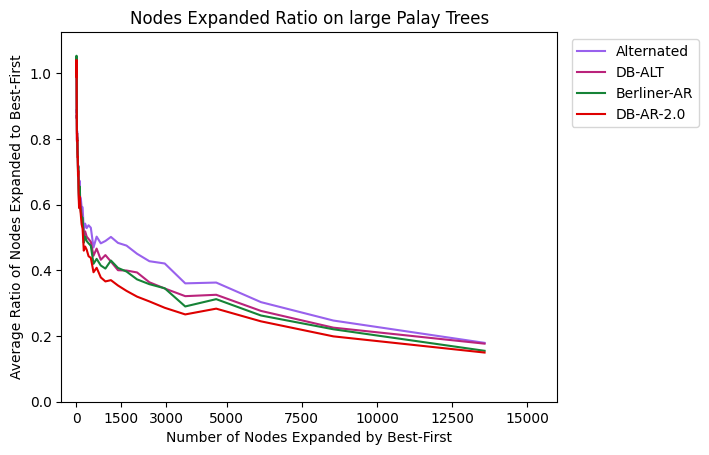

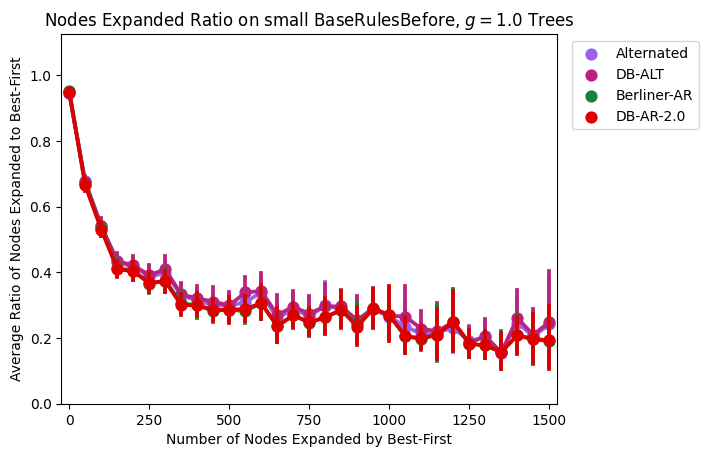

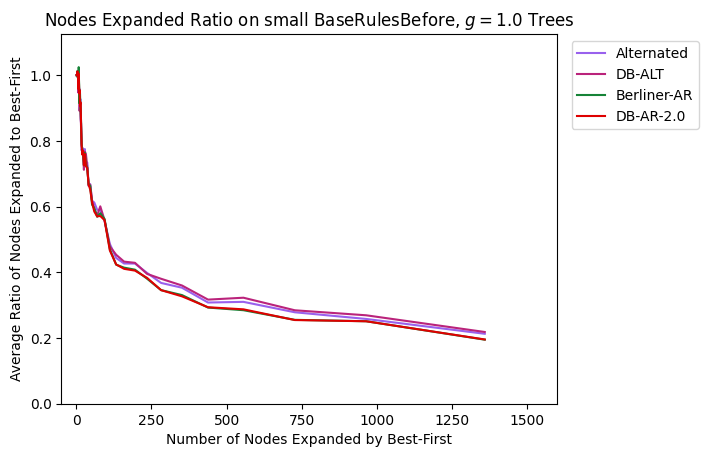

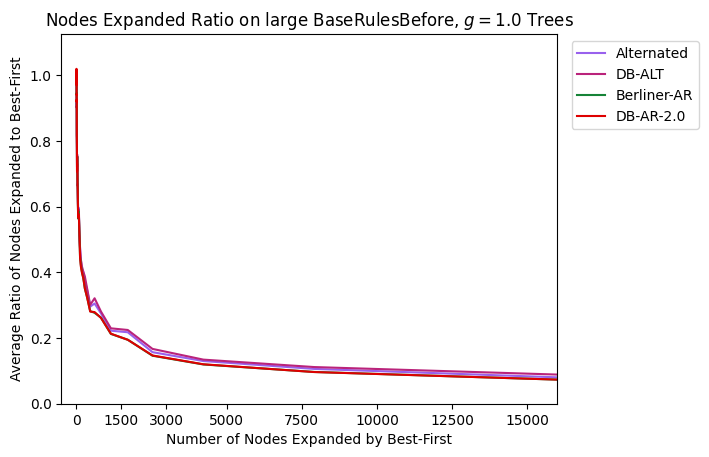

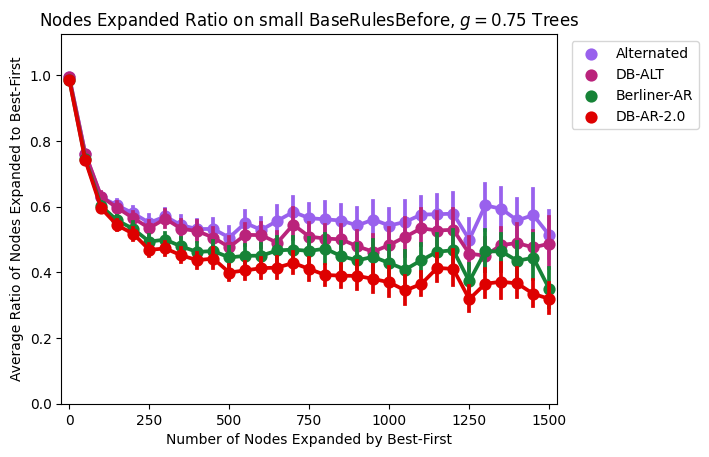

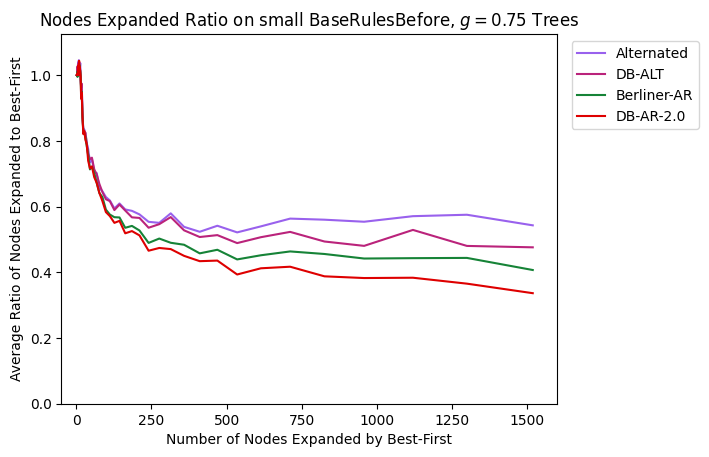

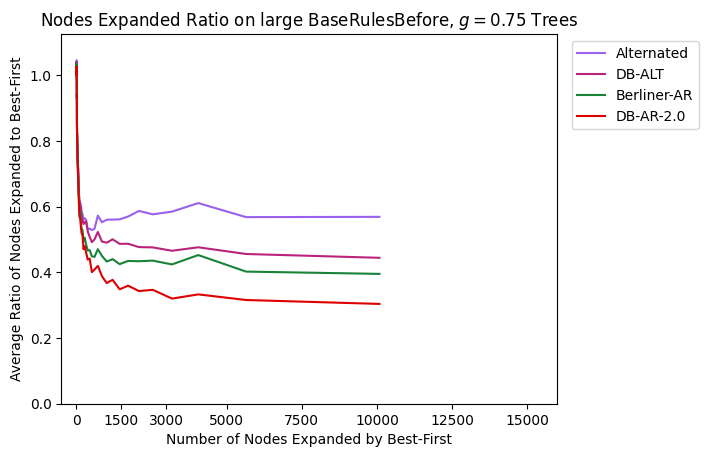

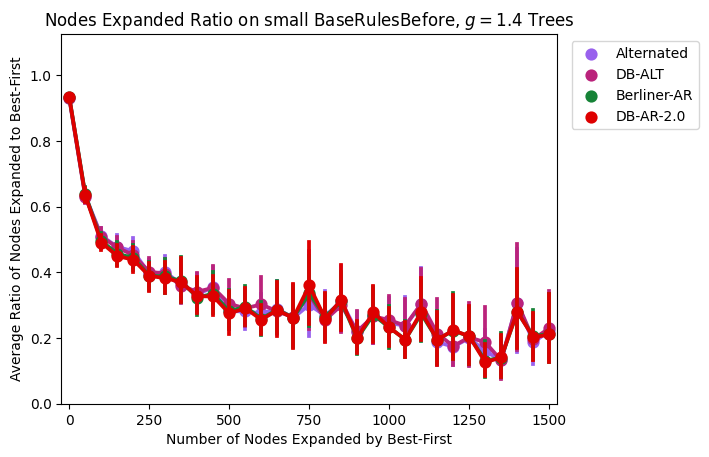

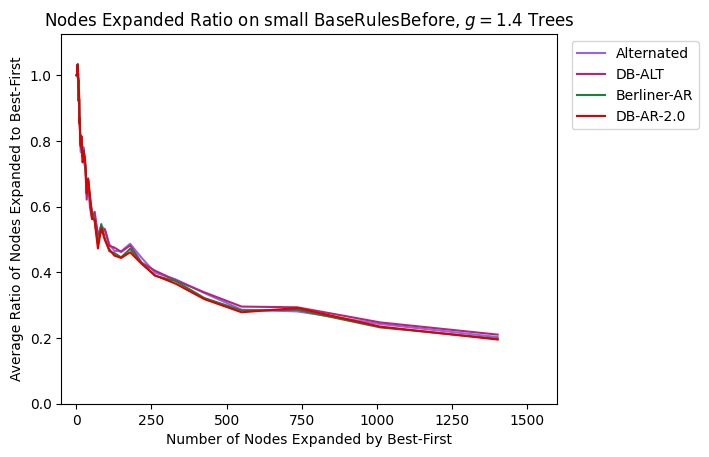

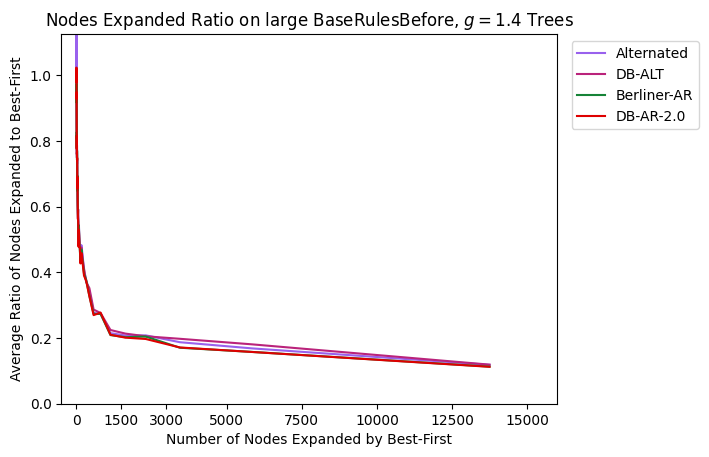

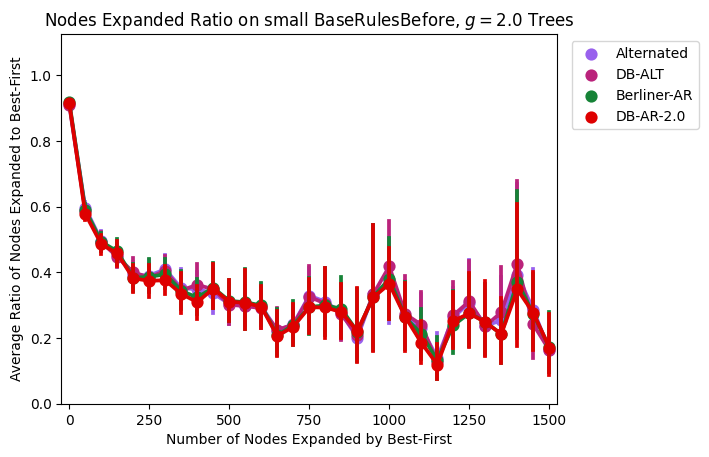

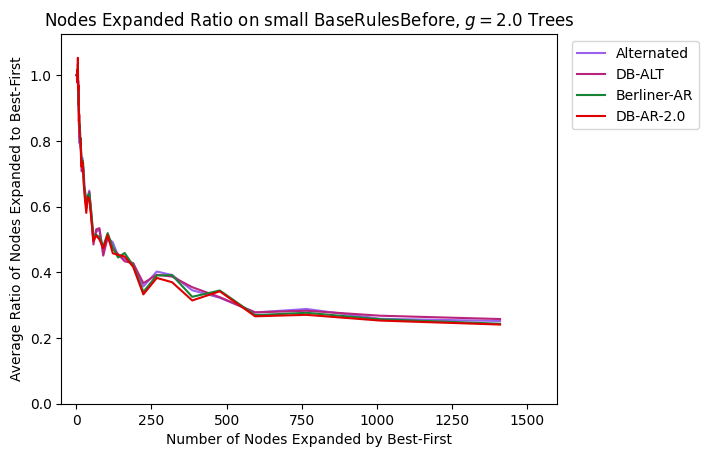

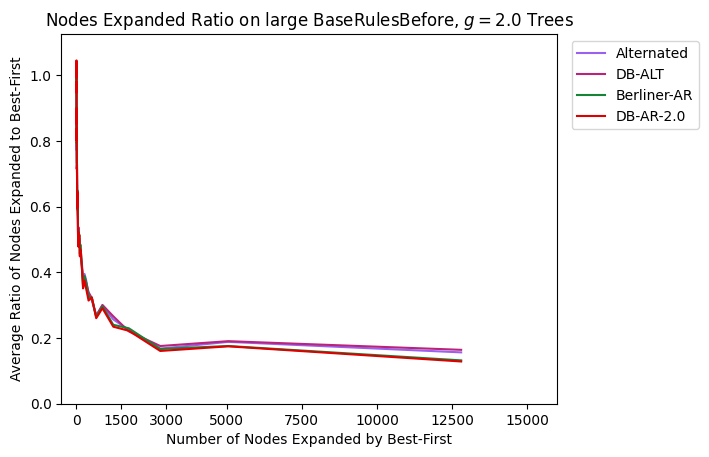

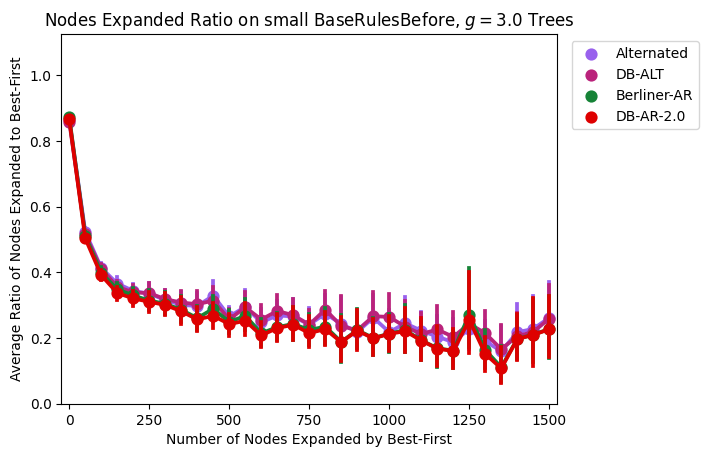

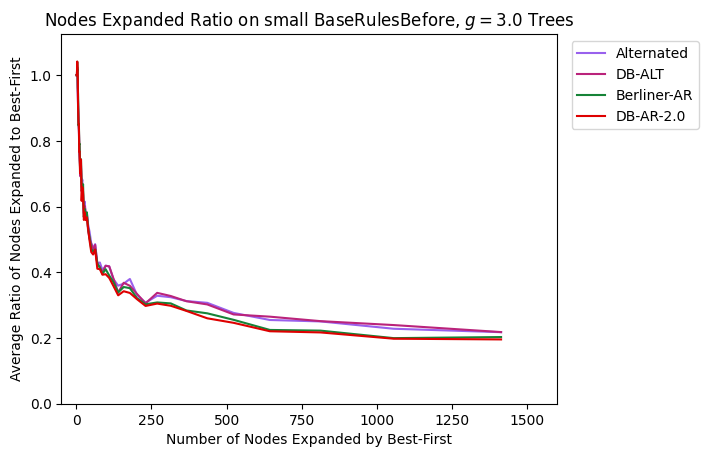

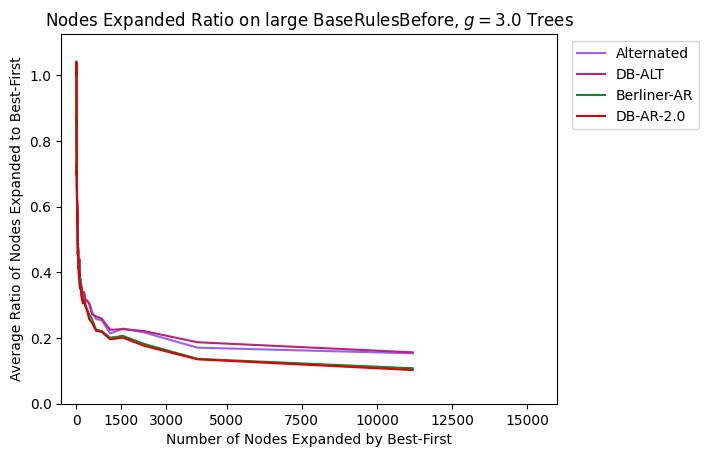

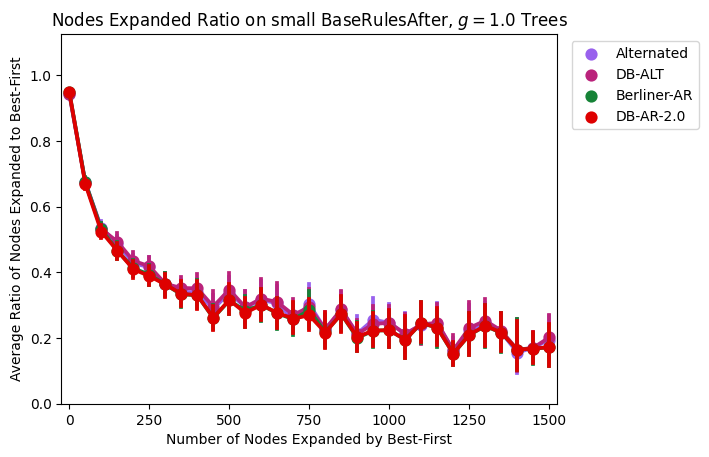

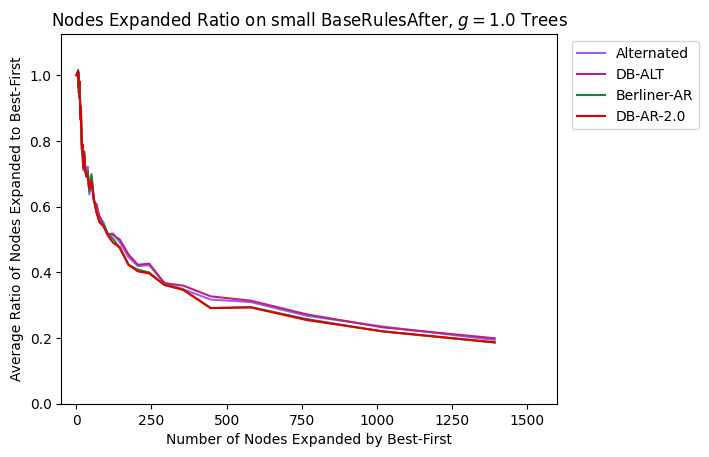

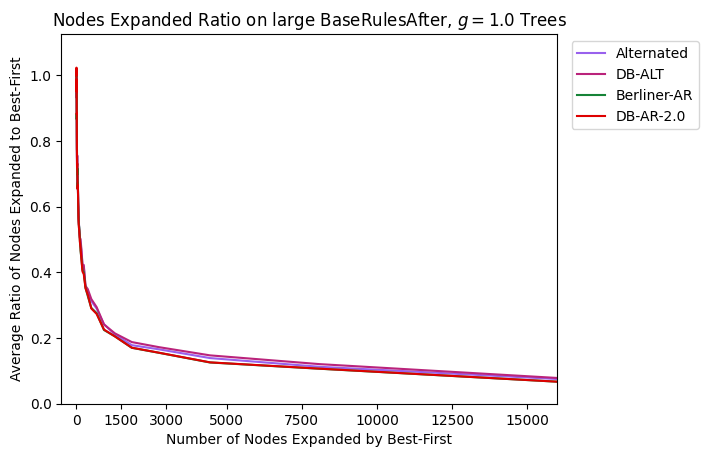

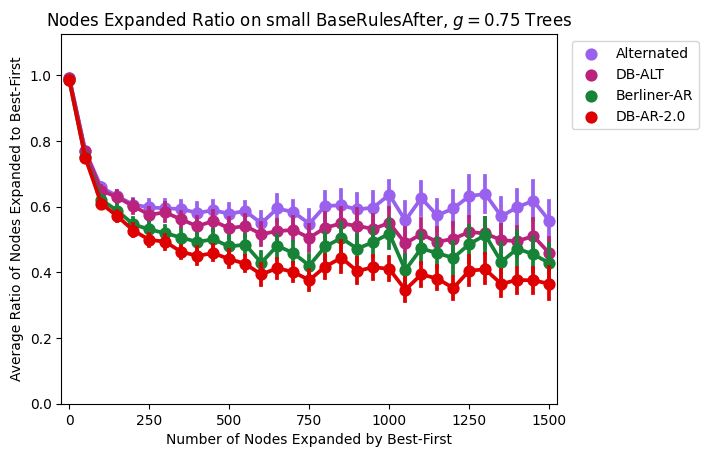

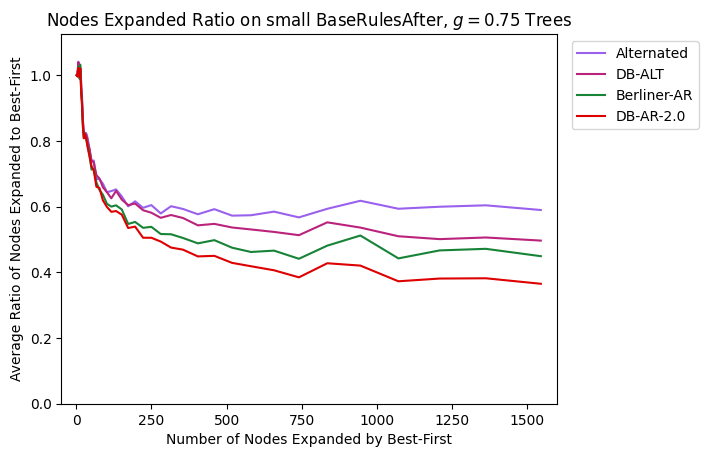

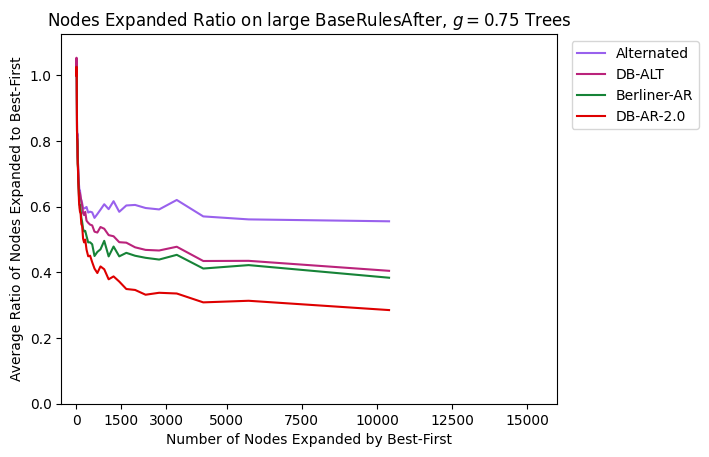

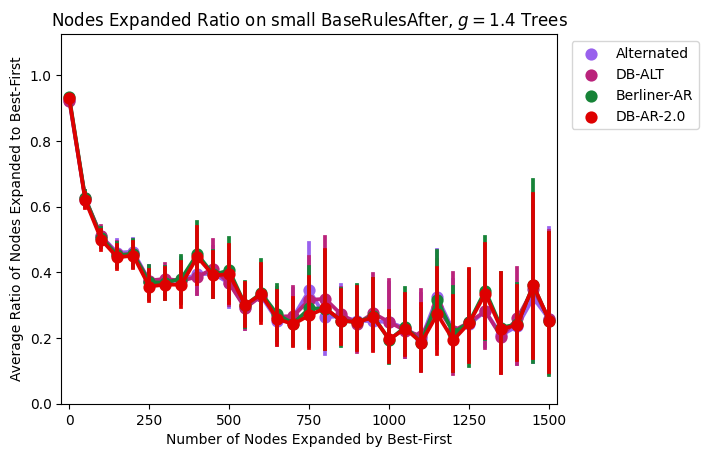

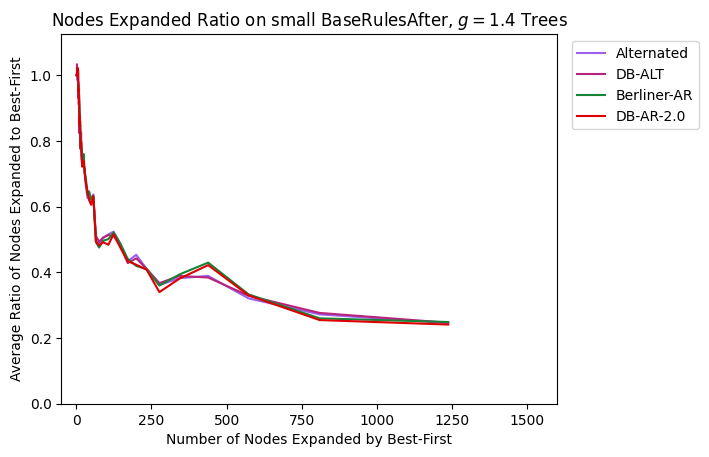

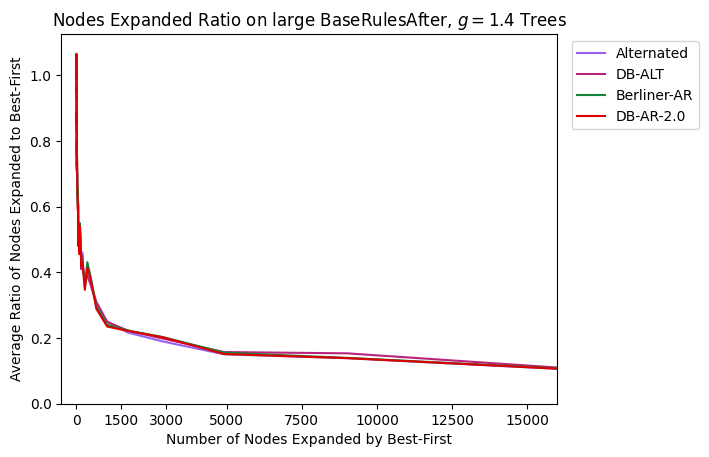

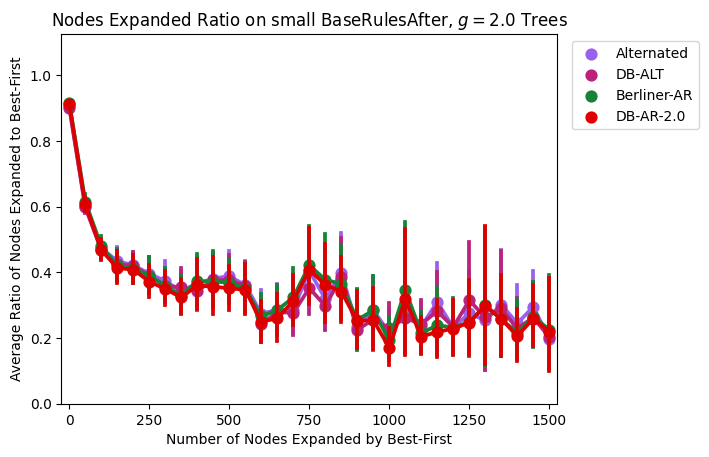

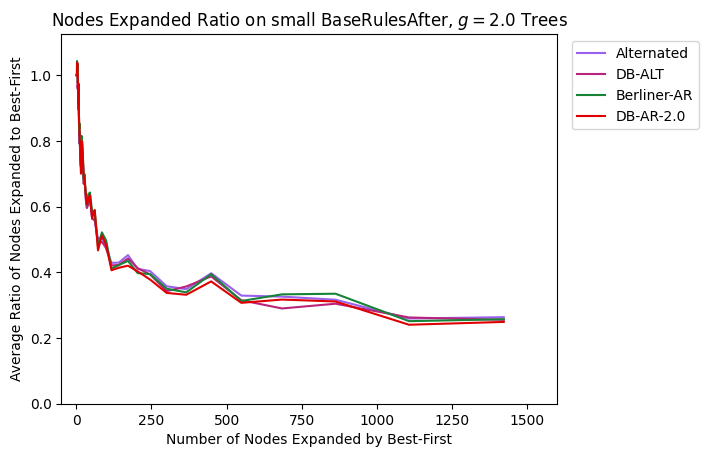

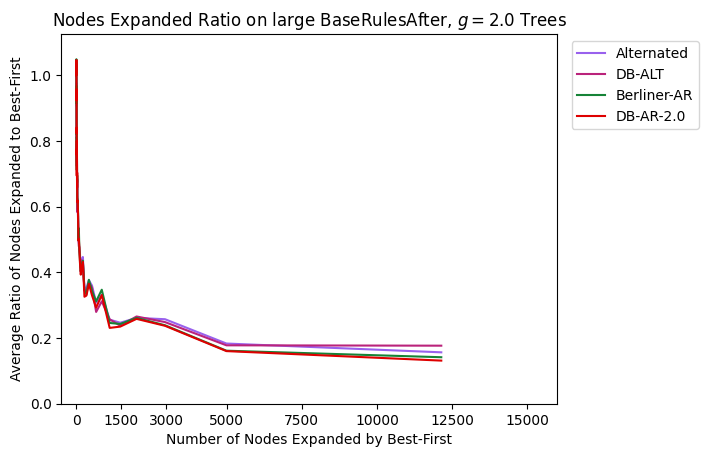

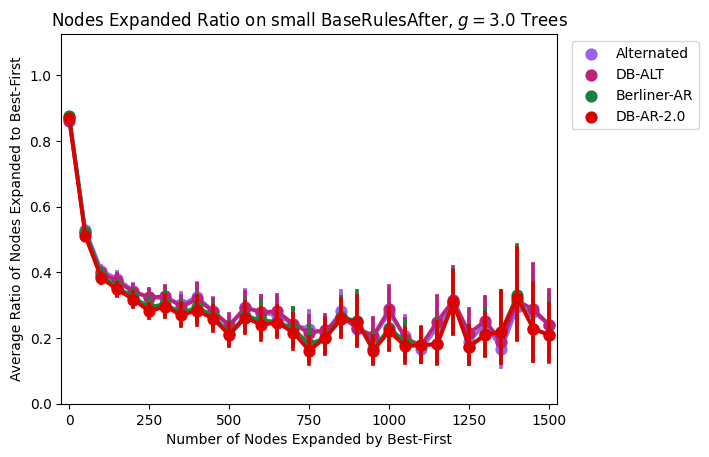

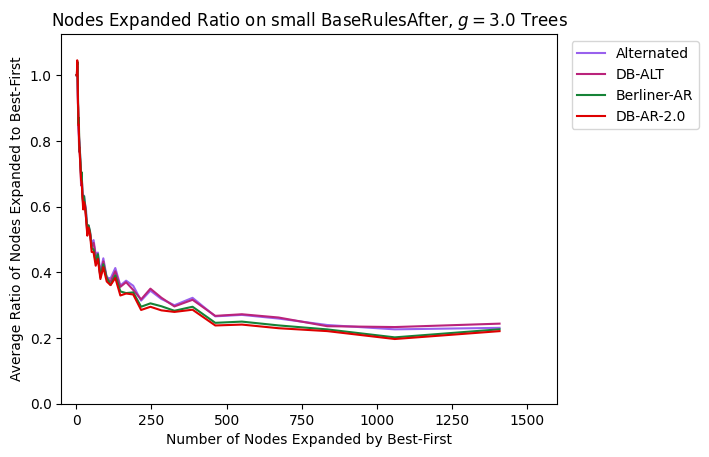

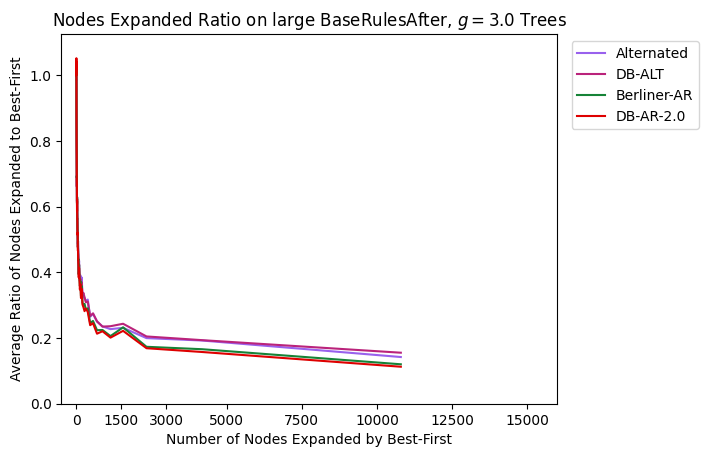

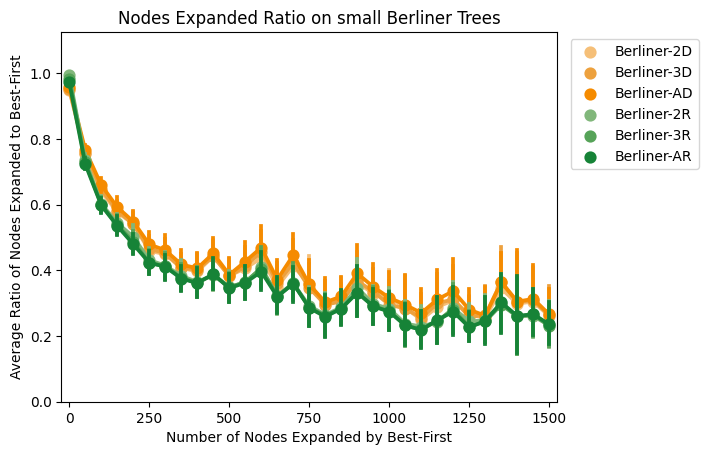

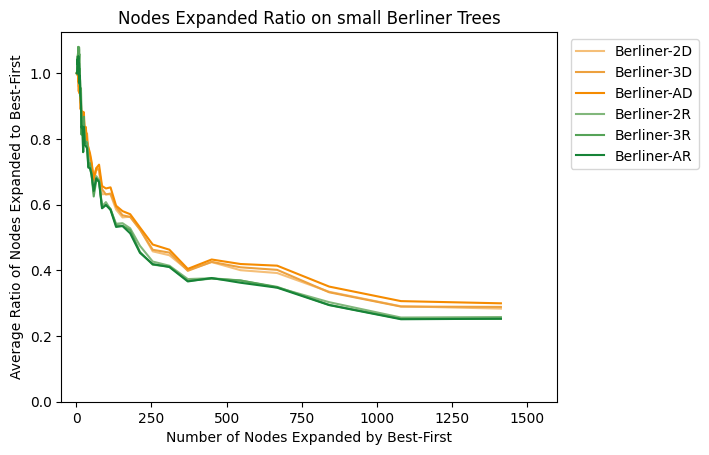

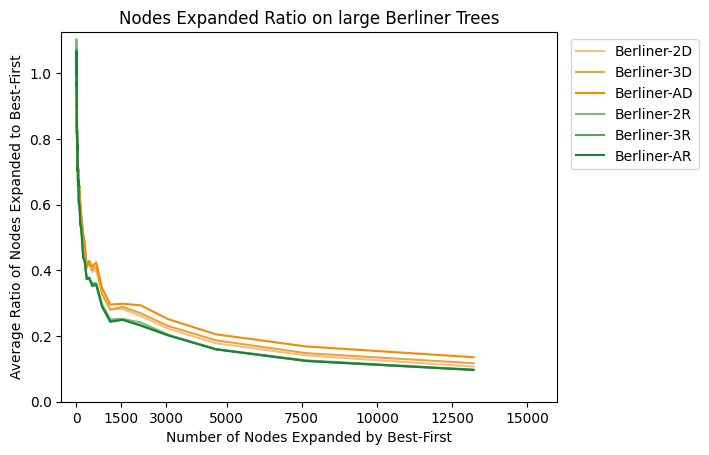

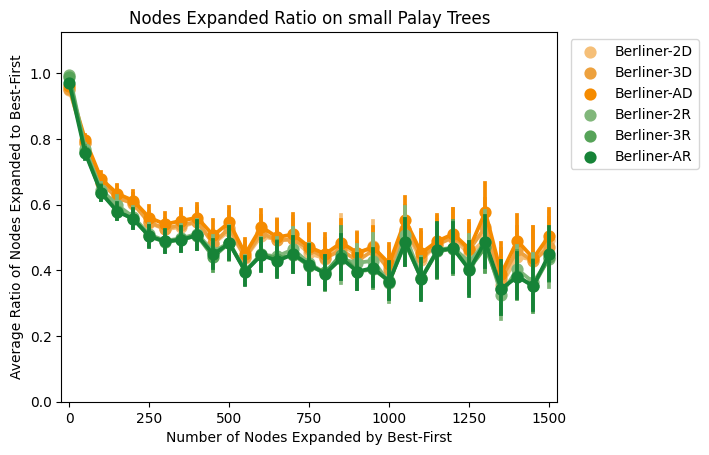

In [ ]:
def set_ticks(ax):
    ax.set_yticks(np.linspace(0,1,6))
    ax.set_ylim((0,1.1))

algorithm_sets = [
    ["alternate", "altern-DB", "berlin-AR", "DB-AR-2.0"],
    [x for x in algos3 if "berlin" in x]
]

for algorithms in algorithm_sets:
    for style in main["style"].unique():
        for growth in main["growth"].unique():
            if style == "Legacy": continue
            if (growth != 1) and (style != "BaseRulesBefore") and (style != "BaseRulesAfter"): continue
            
            growth_string = ""
            if style == "BaseRulesBefore" or style == "BaseRulesAfter": growth_string = f", $g={growth}$"

            ax = pointplot(main_all[(main_all["style"] == style) & (main_all.growth == growth)], algorithms, "expanded", 50, 1500, 3)
            set_ticks(ax)
            plt.ylim((0,1.125))
            plt.xlabel("Number of Nodes Expanded by Best-First")
            plt.ylabel("Average Ratio of Nodes Expanded to Best-First")
            plt.title(f"Nodes Expanded Ratio on small {style}{growth_string} Trees")
            plt.show()

            ax = lineplot(main_all[(main_all["style"] == style) & (main_all.growth == growth)], algorithms, "expanded", 100, 1650, 3, "mean")
            set_ticks(ax)
            plt.ylim((0,1.125))
            ax.set_xticks(np.linspace(0,1500,7))
            ax.set_xlim((-50,1600))
            plt.xlabel("Number of Nodes Expanded by Best-First")
            plt.ylabel("Average Ratio of Nodes Expanded to Best-First")
            plt.title(f"Nodes Expanded Ratio on small {style}{growth_string} Trees")
            plt.show()

            # ax = pointplot(main_all[(main_all["style"] == style) & (main_all.growth == growth)], algorithms, "expanded", 500, 15000, 3)
            # set_ticks(ax)
            # plt.ylim((0,1.125))
            # plt.xlabel("Number of Nodes Expanded by Best-First")
            # plt.ylabel("Average Ratio of Nodes Expanded to Best-First")
            # plt.title(f"Nodes Expanded Ratio on large {style}{growth_string} Trees")
            # plt.show()

            if style == "BaseRulesBefore" or style == "BaseRulesAfter": max_size = 28000
            else: max_size = 18000
            ax = lineplot(main_all[(main_all["style"] == style) & (main_all.growth == growth)], algorithms, "expanded", 100, max_size, 3, "mean")
            set_ticks(ax)
            plt.ylim((0,1.125))
            plt.xlabel("Number of Nodes Expanded by Best-First")
            plt.ylabel("Average Ratio of Nodes Expanded to Best-First")
            ax.set_xticks([0, 1500, 3000] + list(np.linspace(5000,15000,5)))
            ax.set_xlim((-500,16000))
            plt.title(f"Nodes Expanded Ratio on large {style}{growth_string} Trees")
            plt.show()

In [173]:
main.expanded = main.expanded.astype(float)
data = get_data_ratios(main[(main["style"] != "BerlinerSplit") & (main["style"] != "Legacy")], algos3[1:], "expanded")

In [174]:
data = data.drop(columns=list(algos)+["force_chance", "PS", "solution", "depth1Pes", "depth2Opt"])

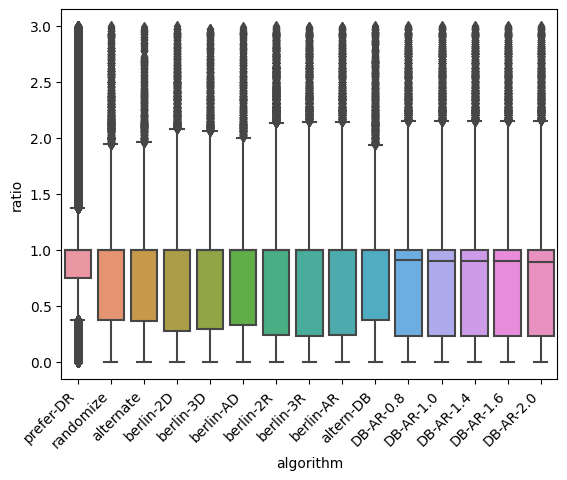

In [175]:
sns.boxplot(data[data.ratio < 3], x="algorithm", y="ratio", order=algos3[1:]);
plt.xticks(rotation=45, ha='right');

In [176]:
len(data[(data.ratio > 3) & (data.algorithm != "prefer-DR")]) / len(data[data.algorithm != "prefer-DR"])

0.0023625448121635485

In [177]:
main_all[main_all.seed == 1022692]

,style,algorithm,growth,PS,num_alts,force_chance,seed,range,width,seconds,depth,evaluated,expanded,solution,depth1Pes,depth2Opt,sepValue
363072,BaseRulesAfter,DB-AR-0.8,2.0,False,6,0.0,1022692,800,4,1.070,206,454173,113543,1,4,3,374.0
363073,BaseRulesAfter,DB-AR-1.0,2.0,False,6,0.0,1022692,800,4,1.629,206,454173,113543,1,4,3,374.0
363074,BaseRulesAfter,DB-AR-1.4,2.0,False,6,0.0,1022692,800,4,1.229,206,454173,113543,1,4,3,374.0
363075,BaseRulesAfter,DB-AR-1.6,2.0,False,6,0.0,1022692,800,4,1.078,206,454173,113543,1,4,3,374.0
363076,BaseRulesAfter,DB-AR-2.0,2.0,False,6,0.0,1022692,800,4,1.233,206,454173,113543,1,4,3,374.0
363077,BaseRulesAfter,altern-DB,2.0,False,6,0.0,1022692,800,4,0.000,7,133,33,1,2,1,406.0
363078,BaseRulesAfter,alternate,2.0,False,6,0.0,1022692,800,4,0.000,7,133,33,1,2,1,406.0
363079,BaseRulesAfter,always-PB,2.0,False,6,0.0,1022692,800,4,0.001,9,269,67,1,2,1,461.0
363080,BaseRulesAfter,berlin-2D,2.0,False,6,0.0,1022692,800,4,0.851,206,454173,113543,1,4,3,374.0
363081,BaseRulesAfter,berlin-2R,2.0,False,6,0.0,1022692,800,4,1.156,206,454145,113536,1,3,4,329.0
